# ST422 Brief 8 — Road Safety Analysis

**Master analysis notebook.** Reads cleaned STATS19 data produced by `Data_Prep/data_cleaning.ipynb` and produces all figures, tables, traceability, and a findings page.

**Run order:** `Data_Prep/data_cleaning.ipynb` → `Data_Analysis/data_analysis.ipynb` (this file).

**Inputs:** `../Data_Prep/Cleaned/{collisions,casualties,vehicles,cas_full}_clean.csv`
**Outputs:** `./Outputs/figures/`, `./Outputs/tables/`, `./Outputs/traceability.csv`, `./Outputs/run_metadata.json`, `./Outputs/findings.html`

**Reproducibility.** All paths relative. The notebook reads cleaned CSVs only — never raw STATS19 files. No LA name is ever hardcoded; no specific year value is hardcoded outside the `BASE_WINDOW_ANCHOR` / `RECENT_WINDOW_ANCHOR` constants in §0, which auto-shift forward when new confirmed years are added to the cleaned data.


## 0. Config

All parameters live here. Methodological choices (window anchors, top-N, thresholds, model filters) are constants the analyst can edit. Year axis, LA list, and ranked candidates are derived from the data at runtime.

**Window anchoring.** `BASE_WINDOW_ANCHOR` and `RECENT_WINDOW_ANCHOR` are *anchors*, not hardcodes. When the cleaned data ends at the anchor's `end` year, the window is honoured exactly. When the data extends past the anchor, both windows shift forward by the offset, preserving the methodological structure (the COVID gap between base and recent). When the anchor is unreachable, falls back to auto-derive. The status print at the end of §0 makes this visible on every run.

In [34]:
import os
import json
import warnings
import glob
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore')

# ── Paths (relative; do not edit when shipping the repo) ──────────────────────
NOTEBOOK_DIR = os.getcwd()                                            # .../Final_Workflow/Data_Analysis
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)                          # .../Final_Workflow
INPUT_DIR    = os.path.join(PROJECT_ROOT, 'Data_Prep', 'Cleaned')
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Data_Prep', 'Data')        # raw inputs (for optional pop file)
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, 'Outputs')
FIG_DIR      = os.path.join(OUTPUT_DIR, 'figures')
TAB_DIR      = os.path.join(OUTPUT_DIR, 'tables')

for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Window anchors ────────────────────────────────────────────────────────────
# Defaults reproduce the windows used in last cycle's reports: a pre-COVID
# 3-year base, a most-recent 3-year window, with a deliberate gap that
# excludes COVID disruption.
#
# Set to None for fully auto-derived windows (last RECENT_N confirmed years
# for recent; the RECENT_N years before that for base, no COVID gap).
BASE_WINDOW_ANCHOR    = (2015, 2017)
RECENT_WINDOW_ANCHOR  = (2022, 2024)
RECENT_N              = 3        # used only when anchors are None

# ── LA OLS trend parameters ──────────────────────────────────────────────────
MIN_KSI_BASE          = 30       # exclude LAs with mean KSI below this in trend window
MIN_YEARS             = 6        # exclude LAs with fewer years of data than this
LOW_R2                = 0.5      # flag LA fits below this R² as 'non-linear shape'
TOP_N_WORSENING       = 5
TOP_N_IMPROVING       = 5
TOP_N_LINES           = 3        # number of LAs shown on combined trend chart

# ── Hotspot parameters ───────────────────────────────────────────────────────
HOTSPOT_N             = 3        # use the last HOTSPOT_N confirmed years
HOTSPOT_TOP_N         = 15       # top-N for hotspot rankings
MIN_COLLISIONS        = 500      # exclude tiny LAs from rate-based ranking

# ── Thresholds ───────────────────────────────────────────────────────────────
MATERIAL_CHANGE_PCT   = 15       # flag LAs with |Δ% KSI| ≥ this between base/recent

# ── Modelling parameters ─────────────────────────────────────────────────────
N_BOOTSTRAP           = 1000
RNG_SEED              = 42

# ── Static constants ─────────────────────────────────────────────────────────
COVID_YEARS           = [2020, 2021]
IBRS_START            = 2016     # collision_adjusted_severity_serious only valid from this year

# ── Choropleth feed (ONS LAD boundaries; updated yearly by ONS) ──────────────
CHOROPLETH_URL = (
    'https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/'
    'Local_Authority_Districts_December_2024_Boundaries_UK_BGC/FeatureServer/0/query'
    '?where=1%3D1&outFields=LAD24CD,LAD24NM&outSR=4326&f=geojson'
)

# ── Plot styling ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 120,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 10,
})
PALETTE = {
    'fatal':      '#c0392b',
    'serious':    '#e67e22',
    'slight':     '#2980b9',
    'ksi':        '#8e44ad',
    'adjusted':   '#2ecc71',
    'raw':        '#e67e22',
    'urban':      '#2980b9',
    'rural':      '#e67e22',
    'covid':      '#7f8c8d',
    'worsening':  '#c0392b',
    'improving':  '#27ae60',
    'neutral':    '#95a5a6',
}

def savefig(name):
    """Helper for consistent figure saving."""
    path = os.path.join(FIG_DIR, f'{name}.png')
    plt.savefig(path)
    return path

print('Paths:')
print(f'  INPUT_DIR  : {INPUT_DIR}  (exists: {os.path.exists(INPUT_DIR)})')
print(f'  DATA_DIR   : {DATA_DIR}   (exists: {os.path.exists(DATA_DIR)})')
print(f'  OUTPUT_DIR : {OUTPUT_DIR}')


Paths:
  INPUT_DIR  : /dcs/large/u2207745/ST422_Team1_Project/Final_Workflow/Data_Prep/Cleaned  (exists: True)
  DATA_DIR   : /dcs/large/u2207745/ST422_Team1_Project/Final_Workflow/Data_Prep/Data   (exists: True)
  OUTPUT_DIR : /dcs/large/u2207745/ST422_Team1_Project/Final_Workflow/Data_Analysis/Outputs


## 1. Load cleaned data, resolve windows, apply completeness filter

(1.1) Load CSVs and derive the year axis from the data. (1.2) Schema assertion. (1.3) Resolve `BASE_WINDOW` and `RECENT_WINDOW` from the anchors. (1.4) Apply the completeness filter — LA must have a record in every year of both windows.

### 1.1 Load

In [35]:
col      = pd.read_csv(os.path.join(INPUT_DIR, 'collisions_clean.csv'), low_memory=False)
cas      = pd.read_csv(os.path.join(INPUT_DIR, 'casualties_clean.csv'),  low_memory=False)
veh      = pd.read_csv(os.path.join(INPUT_DIR, 'vehicles_clean.csv'),    low_memory=False)
cas_full = pd.read_csv(os.path.join(INPUT_DIR, 'cas_full.csv'),          low_memory=False)

for df in [col, cas, veh, cas_full]:
    if 'provisional' in df.columns:
        df['provisional'] = df['provisional'].astype(bool)
    if 'collision_year' in df.columns:
        df['collision_year'] = df['collision_year'].astype(int)
col['ksi']   = col['ksi'].astype(bool)
col['fatal'] = col['fatal'].astype(bool)
col['date']  = pd.to_datetime(col['date'], errors='coerce')

# Derive year axis from data (not constants)
years_present       = sorted(col['collision_year'].unique().tolist())
confirmed_years     = sorted(col.loc[~col['provisional'], 'collision_year'].unique().tolist())
provisional_years   = sorted(col.loc[ col['provisional'], 'collision_year'].unique().tolist())
year_start          = min(confirmed_years)
year_end_confirmed  = max(confirmed_years)
provisional_year    = max(provisional_years) if provisional_years else None

trend_window        = (year_start, year_end_confirmed)
hotspot_window      = (year_end_confirmed - HOTSPOT_N + 1, year_end_confirmed)

print(f'col      : {len(col):>10,} rows')
print(f'cas      : {len(cas):>10,} rows')
print(f'veh      : {len(veh):>10,} rows')
print(f'cas_full : {len(cas_full):>10,} rows')
print()
print(f'Confirmed years   : {year_start}–{year_end_confirmed}')
print(f'Provisional year  : {provisional_year if provisional_year else "(none)"}')
print(f'Trend window      : {trend_window[0]}–{trend_window[1]}')
print(f'Hotspot window    : {hotspot_window[0]}–{hotspot_window[1]} (last {HOTSPOT_N} confirmed years)')


col      :  1,347,870 rows
cas      :  1,748,311 rows
veh      :  2,469,085 rows
cas_full :  1,748,311 rows

Confirmed years   : 2014–2024
Provisional year  : 2025
Trend window      : 2014–2024
Hotspot window    : 2022–2024 (last 3 confirmed years)


### 1.2 Schema assertion

If this errors, the schema in `data_cleaning.ipynb` has drifted. Fix upstream, regenerate `Cleaned/`, rerun.

In [36]:
REQUIRED_COL = {
    'collision_index', 'collision_year', 'date', 'month', 'day_of_week', 'day_label',
    'collision_severity', 'ksi', 'fatal',
    'speed_limit', 'road_type', 'road_type_label',
    'junction_detail', 'junction_label',
    'urban_or_rural_area', 'ur_label',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'police_force', 'force_name',
    'local_authority_ons_district', 'la_name',
    'latitude', 'longitude',
    'collision_adjusted_severity_serious', 'collision_injury_based',
    'provisional',
}
REQUIRED_CAS = {'collision_index', 'collision_year', 'casualty_type', 'casualty_severity',
                'casualty_class', 'road_user', 'provisional'}
REQUIRED_VEH = {'collision_index', 'collision_year', 'vehicle_reference', 'vehicle_type', 'provisional'}
REQUIRED_CASFULL = REQUIRED_CAS | {'la_name', 'ksi', 'speed_limit', 'urban_or_rural_area'}

def assert_schema(df, required, name):
    missing = required - set(df.columns)
    assert not missing, f'{name}: missing columns {sorted(missing)}'

assert_schema(col,      REQUIRED_COL,     'collisions_clean')
assert_schema(cas,      REQUIRED_CAS,     'casualties_clean')
assert_schema(veh,      REQUIRED_VEH,     'vehicles_clean')
assert_schema(cas_full, REQUIRED_CASFULL, 'cas_full')
assert col['provisional'].dtype == bool
assert col['ksi'].dtype == bool
assert col['fatal'].dtype == bool
assert col['la_name'].notna().mean() > 0.95
print('Schema OK.')


Schema OK.


### 1.3 Resolve windows from anchors

If anchors fit the data, honour them exactly (Caleb's report numbers reproduce). If the data has shifted past the anchor, shift both windows forward by the same offset to preserve the COVID gap. If unreachable, fall back to auto-derive.

In [37]:
def resolve_window(anchor, role, confirmed_years, recent_n):
    """
    role: 'base' or 'recent'
    Returns ((start, end), status_string).
    """
    if anchor is None:
        if role == 'recent':
            w = (confirmed_years[-recent_n], confirmed_years[-1])
        else:
            w = (confirmed_years[-2*recent_n], confirmed_years[-recent_n - 1])
        return w, f'auto-derived ({w[0]}–{w[1]})'
    start, end = anchor
    if start in confirmed_years and end in confirmed_years:
        return anchor, f'anchor honoured ({start}–{end})'
    years_past = max(0, confirmed_years[-1] - end)
    shifted = (start + years_past, end + years_past)
    if shifted[0] in confirmed_years and shifted[1] in confirmed_years:
        return shifted, f'anchor ({start}–{end}) shifted +{years_past}y to ({shifted[0]}–{shifted[1]})'
    if role == 'recent':
        w = (confirmed_years[-recent_n], confirmed_years[-1])
    else:
        w = (confirmed_years[-2*recent_n], confirmed_years[-recent_n - 1])
    return w, f'anchor unreachable; fallback to auto-derived ({w[0]}–{w[1]})'

base_window,   base_status   = resolve_window(BASE_WINDOW_ANCHOR,   'base',   confirmed_years, RECENT_N)
recent_window, recent_status = resolve_window(RECENT_WINDOW_ANCHOR, 'recent', confirmed_years, RECENT_N)
BASE_YEARS   = list(range(base_window[0],   base_window[1]   + 1))
RECENT_YEARS = list(range(recent_window[0], recent_window[1] + 1))

print(f'Base window:   {base_status}')
print(f'Recent window: {recent_status}')
print(f'BASE_YEARS   : {BASE_YEARS}')
print(f'RECENT_YEARS : {RECENT_YEARS}')


Base window:   anchor honoured (2015–2017)
Recent window: anchor honoured (2022–2024)
BASE_YEARS   : [2015, 2016, 2017]
RECENT_YEARS : [2022, 2023, 2024]


### 1.4 Completeness filter

LA must have a record in every year of both `BASE_YEARS` and `RECENT_YEARS`. This excludes LAs whose ONS codes were affected by boundary reorganisations (Cumberland, Westmorland & Furness, North/West/East Northamptonshire, North Yorkshire unitary, Buckinghamshire merger, etc.) and any LA missing data in either window.

In [38]:
def complete_las(df, years):
    return set(
        df[df['collision_year'].isin(years)]
        .groupby('la_name')['collision_year'].nunique()
        .pipe(lambda s: s[s == len(years)].index)
    )

complete_set = complete_las(col, BASE_YEARS) & complete_las(col, RECENT_YEARS)
n_total      = col['la_name'].nunique()
n_complete   = len(complete_set)
n_dropped    = n_total - n_complete

print(f'LAs in cleaned data       : {n_total}')
print(f'LAs passing completeness  : {n_complete}  (data in every year of base AND recent windows)')
print(f'LAs dropped               : {n_dropped}')

# Apply filter (keep originals available for sensitivity)
col_raw      = col.copy()
cas_full_raw = cas_full.copy()

col      = col[col['la_name'].isin(complete_set)].copy()
if 'la_name' in cas_full.columns:
    cas_full = cas_full[cas_full['la_name'].isin(complete_set)].copy()


LAs in cleaned data       : 392
LAs passing completeness  : 340  (data in every year of base AND recent windows)
LAs dropped               : 52


## 2. Data quality — missingness and IBRS adoption (Fig 1)

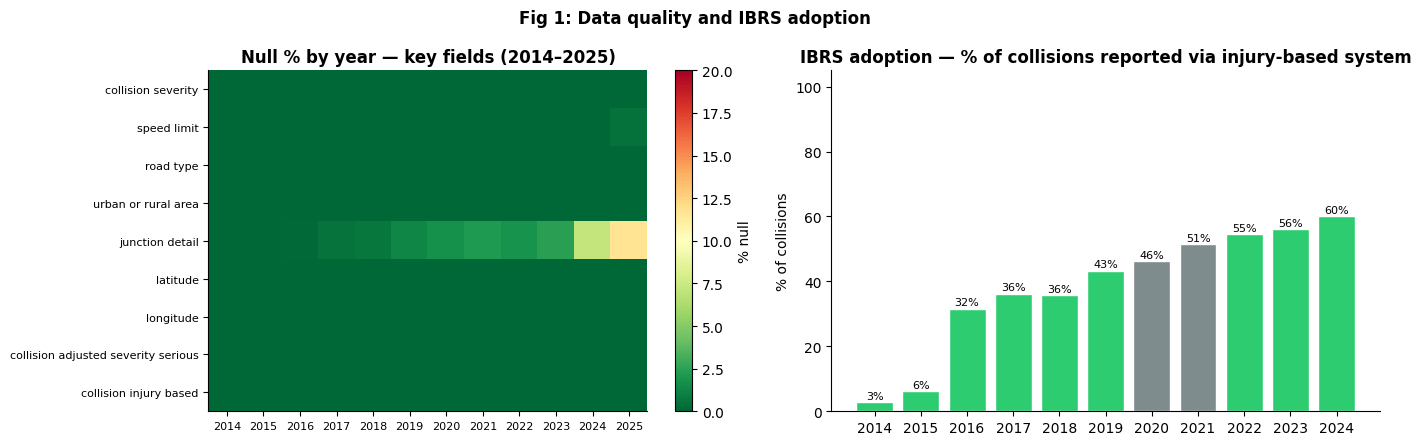

In [39]:
KEY_FIELDS = ['collision_severity', 'speed_limit', 'road_type', 'urban_or_rural_area',
              'junction_detail', 'latitude', 'longitude',
              'collision_adjusted_severity_serious', 'collision_injury_based']

null_by_year = []
for yr in years_present:
    sub = col[col['collision_year'] == yr]
    row = {'collision_year': yr}
    for f in KEY_FIELDS:
        row[f] = sub[f].isna().mean() * 100
    null_by_year.append(row)
null_df = pd.DataFrame(null_by_year)
null_df.to_csv(os.path.join(TAB_DIR, 'tab_null_rates_by_year.csv'), index=False)

ibrs = (col[~col['provisional']]
        .assign(ibrs_flag=lambda d: (d['collision_injury_based'] == 1).astype(int))
        .groupby('collision_year')['ibrs_flag']
        .mean().mul(100).round(1)
        .reset_index(name='ibrs_pct'))
ibrs.to_csv(os.path.join(TAB_DIR, 'tab_ibrs_adoption.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
heat = null_df.set_index('collision_year')[KEY_FIELDS].T
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=20)
ax.set_yticks(range(len(KEY_FIELDS)))
ax.set_yticklabels([f.replace('_', ' ') for f in KEY_FIELDS], fontsize=8)
ax.set_xticks(range(len(years_present)))
ax.set_xticklabels(years_present, fontsize=8)
ax.set_title(f'Null % by year — key fields ({year_start}–{years_present[-1]})')
plt.colorbar(im, ax=ax, label='% null')

ax = axes[1]
colors = [PALETTE['covid'] if y in COVID_YEARS else PALETTE['adjusted'] for y in ibrs['collision_year']]
ax.bar(ibrs['collision_year'], ibrs['ibrs_pct'], color=colors, edgecolor='white')
for x, v in zip(ibrs['collision_year'], ibrs['ibrs_pct']):
    ax.text(x, v + 1, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_title('IBRS adoption — % of collisions reported via injury-based system')
ax.set_ylabel('% of collisions')
ax.set_ylim(0, 105)
ax.set_xticks(ibrs['collision_year'])

plt.suptitle('Fig 1: Data quality and IBRS adoption', fontweight='bold')
plt.tight_layout()
savefig('fig01_missingness_ibrs')
plt.show()


## 3. KSI trends

### 3a Provisional-year seasonality check (Fig 2)

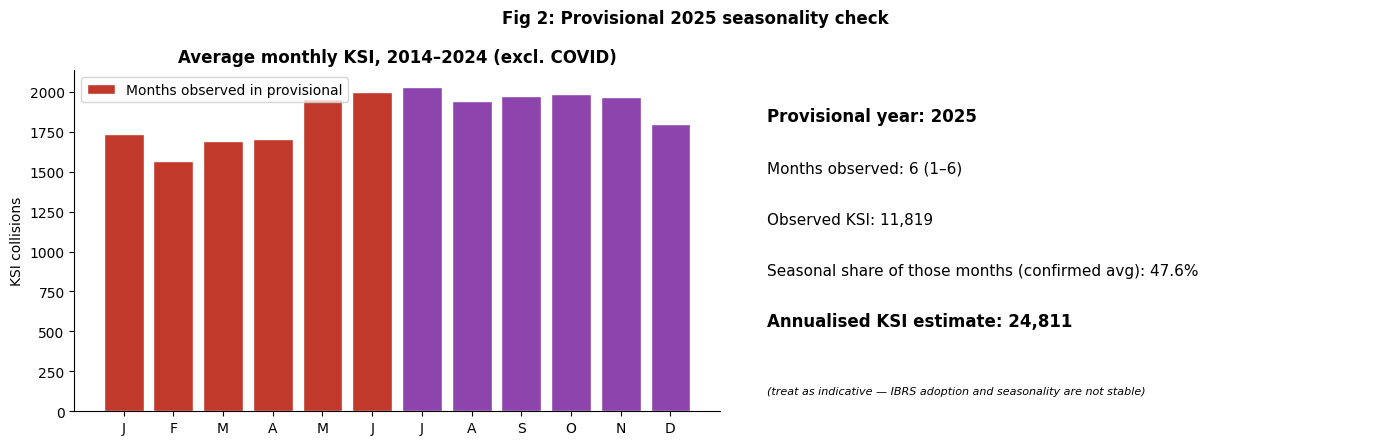

In [40]:
if provisional_year is None:
    print('No provisional year — Fig 2 skipped.')
    seasonal_factor = None
else:
    non_covid_confirmed = [y for y in confirmed_years if y not in COVID_YEARS]
    monthly_conf = (col[(col['collision_year'].isin(non_covid_confirmed)) & col['ksi']]
                    .groupby([col['collision_year'], col['month']])
                    .size().unstack(fill_value=0))
    prov = col[(col['collision_year'] == provisional_year) & col['ksi']]
    prov_months_observed = sorted(prov['month'].dropna().unique().astype(int).tolist())
    n_prov_months = len(prov_months_observed)
    prov_ksi      = len(prov)
    h1_share      = monthly_conf[prov_months_observed].sum(axis=1).div(monthly_conf.sum(axis=1)).mean()
    annualised    = prov_ksi / h1_share if h1_share else np.nan
    seasonal_factor = h1_share

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ax = axes[0]
    avg_monthly = monthly_conf.mean(axis=0)
    ax.bar(avg_monthly.index, avg_monthly.values, color=PALETTE['ksi'], edgecolor='white')
    for m in prov_months_observed:
        ax.bar(m, avg_monthly.loc[m], color=PALETTE['fatal'], edgecolor='white',
               label='Months observed in provisional' if m == prov_months_observed[0] else None)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_title(f'Average monthly KSI, {non_covid_confirmed[0]}–{non_covid_confirmed[-1]} (excl. COVID)')
    ax.set_ylabel('KSI collisions')
    ax.legend()

    ax = axes[1]
    ax.text(0.05, 0.85, f'Provisional year: {provisional_year}', transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.text(0.05, 0.70, f'Months observed: {n_prov_months} ({prov_months_observed[0]}–{prov_months_observed[-1]})', transform=ax.transAxes, fontsize=11)
    ax.text(0.05, 0.55, f'Observed KSI: {prov_ksi:,}', transform=ax.transAxes, fontsize=11)
    ax.text(0.05, 0.40, f'Seasonal share of those months (confirmed avg): {h1_share*100:.1f}%', transform=ax.transAxes, fontsize=11)
    ax.text(0.05, 0.25, f'Annualised KSI estimate: {annualised:,.0f}', transform=ax.transAxes, fontsize=12, fontweight='bold')
    ax.text(0.05, 0.05, '(treat as indicative — IBRS adoption and seasonality are not stable)', transform=ax.transAxes, fontsize=8, style='italic')
    ax.axis('off')

    plt.suptitle(f'Fig 2: Provisional {provisional_year} seasonality check', fontweight='bold')
    plt.tight_layout()
    savefig('fig02_seasonality')
    plt.show()


### 3b National KSI trend over confirmed years (Fig 3)

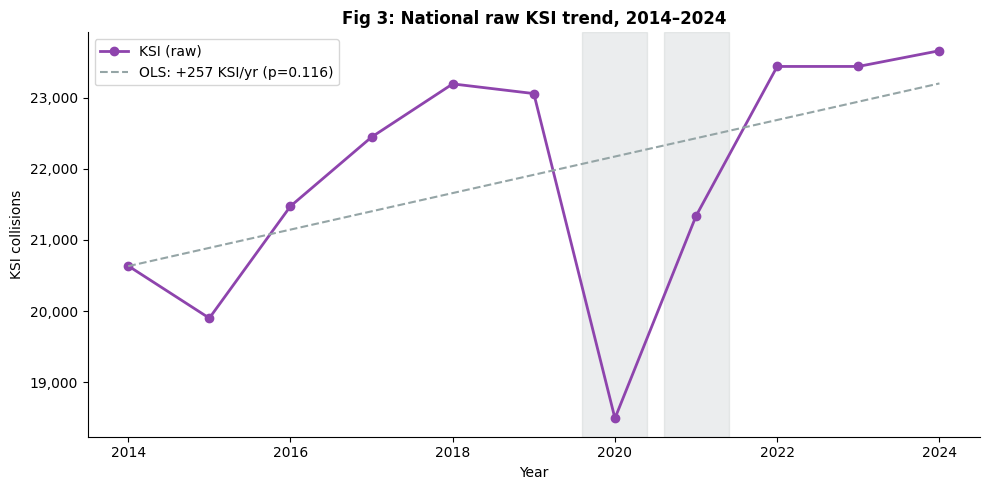

Raw KSI slope: +256.6 per year (95% CI -32.6 to +545.8, p=0.1160)


In [41]:
annual = (col[~col['provisional']]
          .groupby('collision_year')
          .agg(fatal=('fatal', 'sum'),
               serious=('collision_severity', lambda x: (x == 2).sum()),
               total_collisions=('collision_index', 'count'))
          .reset_index())
annual['ksi'] = annual['fatal'] + annual['serious']
annual.to_csv(os.path.join(TAB_DIR, 'tab_ksi_trend_national.csv'), index=False)

slope_raw, intercept_raw, r_raw, p_raw, se_raw = stats.linregress(annual['collision_year'], annual['ksi'])

fig, ax = plt.subplots(figsize=(10, 5))
for yr in COVID_YEARS:
    if yr in annual['collision_year'].values:
        ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.15, color=PALETTE['covid'], zorder=0)
ax.plot(annual['collision_year'], annual['ksi'], marker='o', color=PALETTE['ksi'], lw=2, label='KSI (raw)')
xs = annual['collision_year']
ax.plot(xs, intercept_raw + slope_raw * xs, '--', color=PALETTE['neutral'], label=f'OLS: {slope_raw:+.0f} KSI/yr (p={p_raw:.3f})')
ax.set_title(f'Fig 3: National raw KSI trend, {year_start}–{year_end_confirmed}')
ax.set_ylabel('KSI collisions')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
savefig('fig03_national_ksi_trend')
plt.show()

print(f'Raw KSI slope: {slope_raw:+.1f} per year (95% CI {slope_raw - 1.96*se_raw:+.1f} to {slope_raw + 1.96*se_raw:+.1f}, p={p_raw:.4f})')


### 3c Raw vs IBRS-adjusted KSI (Fig 4)

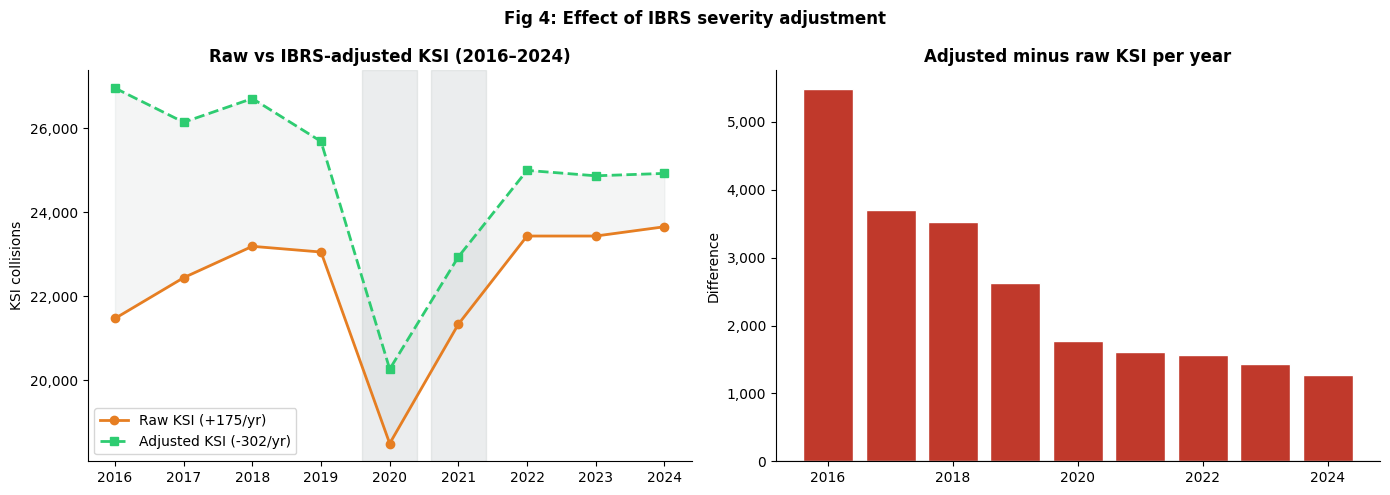

Raw KSI slope (2016–2024)      : +174.7/yr  (p=0.4504)
Adjusted KSI slope (2016–2024) : -302.1/yr  (p=0.2918)


In [42]:
ibrs_w = col[(col['collision_year'] >= IBRS_START) &
             (col['collision_year'] <= year_end_confirmed) &
             (~col['provisional'])].copy()

adj = (ibrs_w.groupby('collision_year').agg(
            raw_fatal   = ('fatal', 'sum'),
            raw_serious = ('collision_severity', lambda x: (x == 2).sum()),
            adj_serious = ('collision_adjusted_severity_serious', 'sum'),
            ibrs_pct    = ('collision_injury_based', lambda x: (x == 1).mean() * 100))
       .reset_index())
adj['raw_ksi'] = adj['raw_fatal'] + adj['raw_serious']
adj['adj_ksi'] = adj['raw_fatal'] + adj['adj_serious']
adj.to_csv(os.path.join(TAB_DIR, 'tab_ksi_raw_vs_adjusted.csv'), index=False)

slope_raw_w, _, _, p_raw_w, se_raw_w = stats.linregress(adj['collision_year'], adj['raw_ksi'])
slope_adj_w, _, _, p_adj_w, se_adj_w = stats.linregress(adj['collision_year'], adj['adj_ksi'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for yr in COVID_YEARS:
    if yr in adj['collision_year'].values:
        ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.15, color=PALETTE['covid'], zorder=0)
ax.plot(adj['collision_year'], adj['raw_ksi'], marker='o', lw=2, color=PALETTE['raw'], label=f'Raw KSI ({slope_raw_w:+.0f}/yr)')
ax.plot(adj['collision_year'], adj['adj_ksi'], marker='s', lw=2, linestyle='--', color=PALETTE['adjusted'], label=f'Adjusted KSI ({slope_adj_w:+.0f}/yr)')
ax.fill_between(adj['collision_year'], adj['raw_ksi'], adj['adj_ksi'], alpha=0.1, color=PALETTE['neutral'])
ax.set_title(f'Raw vs IBRS-adjusted KSI ({IBRS_START}–{year_end_confirmed})')
ax.set_ylabel('KSI collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

ax = axes[1]
gap = adj['adj_ksi'] - adj['raw_ksi']
ax.bar(adj['collision_year'], gap, edgecolor='white',
       color=[PALETTE['fatal'] if g > 0 else PALETTE['adjusted'] for g in gap])
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Adjusted minus raw KSI per year')
ax.set_ylabel('Difference')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 4: Effect of IBRS severity adjustment', fontweight='bold')
plt.tight_layout()
savefig('fig04_raw_vs_adjusted')
plt.show()

print(f'Raw KSI slope ({IBRS_START}–{year_end_confirmed})      : {slope_raw_w:+.1f}/yr  (p={p_raw_w:.4f})')
print(f'Adjusted KSI slope ({IBRS_START}–{year_end_confirmed}) : {slope_adj_w:+.1f}/yr  (p={p_adj_w:.4f})')


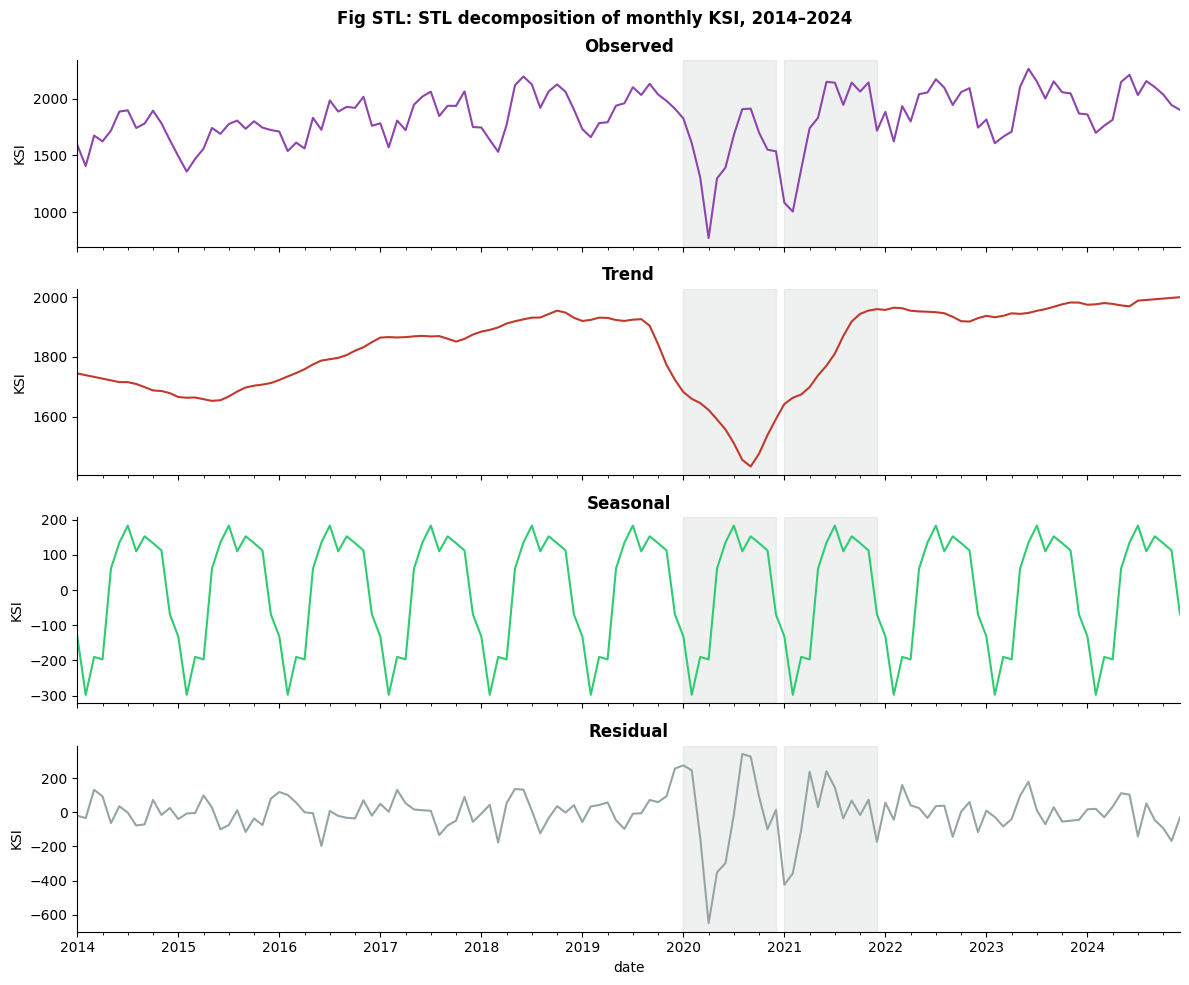

Peak month  : 7  (avg seasonal component: +183/month)
Trough month: 2  (avg seasonal component: -298/month)
Seasonal amplitude: 481 KSI/month
Three findings for OLS validation:
  1. Trend broadly linear outside COVID — supports excluding 2020–21 from OLS
  2. Seasonal component stable across all years — does not confound annual totals
  3. Residuals small outside COVID — supports i.i.d. error assumption


In [43]:
# ── §3d STL decomposition of monthly KSI ─────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_ksi = (col[~col['provisional'] & col['ksi']]
               .groupby(['collision_year', 'month'])
               .size()
               .reset_index(name='KSI'))
monthly_ksi['date'] = pd.to_datetime(
    monthly_ksi['collision_year'].astype(str) + '-' +
    monthly_ksi['month'].astype(str).str.zfill(2) + '-01')
monthly_ts = (monthly_ksi.set_index('date')['KSI']
              .asfreq('MS')
              .fillna(0))

decomp = seasonal_decompose(monthly_ts, model='additive', period=12, extrapolate_trend='freq')

# Summary statistics
avg_seasonal = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
peak_month   = int(avg_seasonal.idxmax())
trough_month = int(avg_seasonal.idxmin())

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
titles = ['Observed', 'Trend', 'Seasonal', 'Residual']
series = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colours = [PALETTE['ksi'], PALETTE['fatal'], PALETTE['adjusted'], PALETTE['neutral']]
for ax, s, title, c in zip(axes, series, titles, colours):
    s.plot(ax=ax, color=c, lw=1.5)
    ax.set_title(title)
    ax.set_ylabel('KSI')
    for yr in COVID_YEARS:
        ax.axvspan(f'{yr}-01-01', f'{yr}-12-31', alpha=0.12, color=PALETTE['covid'])

plt.suptitle('Fig STL: STL decomposition of monthly KSI, 2014–2024', fontweight='bold')
plt.tight_layout()
savefig('fig_stl_decomposition')
plt.show()

print(f'Peak month  : {peak_month}  (avg seasonal component: {avg_seasonal[peak_month]:+.0f}/month)')
print(f'Trough month: {trough_month}  (avg seasonal component: {avg_seasonal[trough_month]:+.0f}/month)')
print(f'Seasonal amplitude: {avg_seasonal.max() - avg_seasonal.min():.0f} KSI/month')
print('Three findings for OLS validation:')
print('  1. Trend broadly linear outside COVID — supports excluding 2020–21 from OLS')
print('  2. Seasonal component stable across all years — does not confound annual totals')
print('  3. Residuals small outside COVID — supports i.i.d. error assumption')

## 4. Road user severity profile (Fig 5)

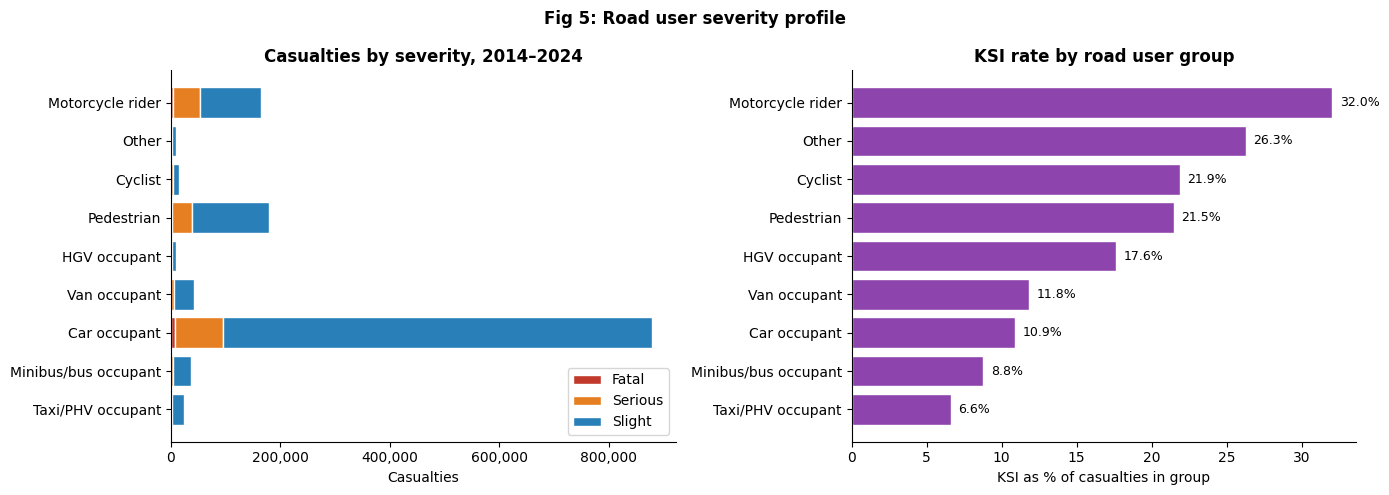

In [44]:
ru_window = cas_full[(cas_full['collision_year'].between(*trend_window)) & (~cas_full['provisional'])].copy()

ru = (ru_window.groupby('road_user')
      .agg(Fatal   = ('casualty_severity', lambda x: (x == 1).sum()),
           Serious = ('casualty_severity', lambda x: (x == 2).sum()),
           Slight  = ('casualty_severity', lambda x: (x == 3).sum()))
      .assign(Total=lambda d: d.sum(axis=1))
      .assign(KSI=lambda d: d['Fatal'] + d['Serious'])
      .assign(KSI_pct  = lambda d: d['KSI']  / d['Total'] * 100,
              Fatal_pct=lambda d: d['Fatal']/ d['Total'] * 100)
      .sort_values('Total', ascending=False))
ru.to_csv(os.path.join(TAB_DIR, 'tab_road_user_severity.csv'))

ru_plot = ru.drop(index='Unknown', errors='ignore').sort_values('KSI_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
bot = np.zeros(len(ru_plot))
for sev, colour in [('Fatal', PALETTE['fatal']), ('Serious', PALETTE['serious']), ('Slight', PALETTE['slight'])]:
    ax.barh(ru_plot.index, ru_plot[sev], left=bot, color=colour, label=sev, edgecolor='white')
    bot += ru_plot[sev].values
ax.set_title(f'Casualties by severity, {trend_window[0]}–{trend_window[1]}')
ax.set_xlabel('Casualties')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right')

ax = axes[1]
ax.barh(ru_plot.index, ru_plot['KSI_pct'], color=PALETTE['ksi'], edgecolor='white')
for y, v in enumerate(ru_plot['KSI_pct']):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=9)
ax.set_title('KSI rate by road user group')
ax.set_xlabel('KSI as % of casualties in group')

plt.suptitle('Fig 5: Road user severity profile', fontweight='bold')
plt.tight_layout()
savefig('fig05_road_user_severity')
plt.show()


## 5. Geographic hotspots — last `HOTSPOT_N` confirmed years

### 5a Top-N by count and rate (Fig 6)

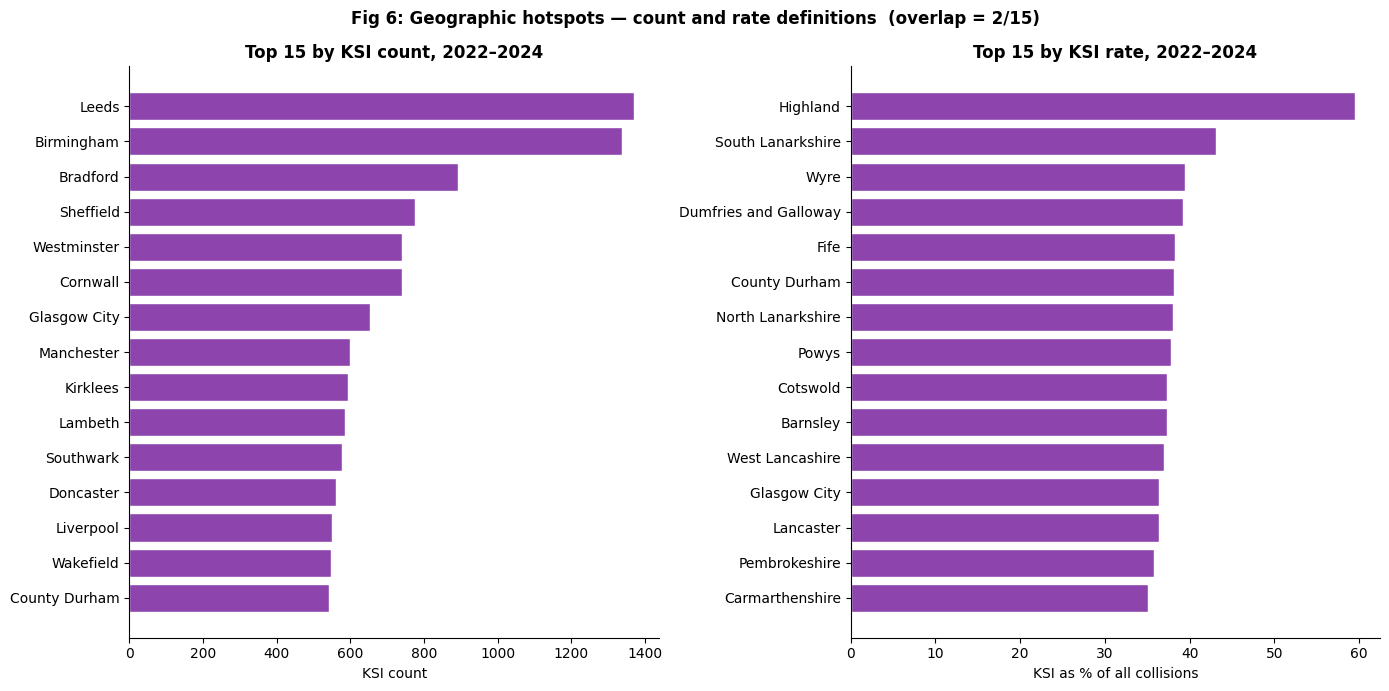

Overlap between count-top-15 and rate-top-15: 2 authorities.


In [45]:
hot = col[(col['collision_year'].between(*hotspot_window)) & (~col['provisional'])].copy()

la = (hot.groupby(['local_authority_ons_district', 'la_name'])
      .agg(KSI       = ('ksi', 'sum'),
           Total     = ('collision_index', 'count'),
           Fatal     = ('fatal', 'sum'))
      .reset_index())
la['KSI_rate']   = la['KSI']   / la['Total'] * 100
la['Fatal_rate'] = la['Fatal'] / la['Total'] * 100

# Filter: present in every year of the hotspot window AND has minimum collision volume
la_years = (hot.groupby('local_authority_ons_district')['collision_year'].nunique()
            .rename('n_years').reset_index())
n_hot = hotspot_window[1] - hotspot_window[0] + 1
keep_codes = la_years.loc[la_years['n_years'] == n_hot, 'local_authority_ons_district']
la = la[la['local_authority_ons_district'].isin(keep_codes)].copy()

# For rate-based ranking only, exclude tiny LAs (Caleb's MIN_COLLISIONS filter)
la_for_rate = la[la['Total'] >= MIN_COLLISIONS].copy()

top_count = la         .sort_values('KSI', ascending=False)     .head(HOTSPOT_TOP_N).reset_index(drop=True)
top_rate  = la_for_rate.sort_values('KSI_rate', ascending=False).head(HOTSPOT_TOP_N).reset_index(drop=True)
top_count.to_csv(os.path.join(TAB_DIR, 'tab_la_hotspots_count.csv'), index=False)
top_rate .to_csv(os.path.join(TAB_DIR, 'tab_la_hotspots_rate.csv'),  index=False)

overlap_codes = set(top_count['local_authority_ons_district']) & set(top_rate['local_authority_ons_district'])
overlap_n     = len(overlap_codes)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, df, title, col_name in [
    (axes[0], top_count, f'Top {HOTSPOT_TOP_N} by KSI count, {hotspot_window[0]}–{hotspot_window[1]}', 'KSI'),
    (axes[1], top_rate,  f'Top {HOTSPOT_TOP_N} by KSI rate, {hotspot_window[0]}–{hotspot_window[1]}',  'KSI_rate'),
]:
    df_p = df.iloc[::-1]
    ax.barh(df_p['la_name'], df_p[col_name], color=PALETTE['ksi'], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('KSI count' if col_name == 'KSI' else 'KSI as % of all collisions')

plt.suptitle(f'Fig 6: Geographic hotspots — count and rate definitions  '
             f'(overlap = {overlap_n}/{HOTSPOT_TOP_N})', fontweight='bold')
plt.tight_layout()
savefig('fig06_hotspots_count_rate')
plt.show()

print(f'Overlap between count-top-{HOTSPOT_TOP_N} and rate-top-{HOTSPOT_TOP_N}: {overlap_n} authorities.')


### 5b Choropleth (Fig 6b)

Fetches ONS LAD boundaries from the live ArcGIS feed. Skipped if fetch fails or geopandas unavailable. The fetch is the only network call in the notebook.

In [46]:
try:
    import geopandas as gpd

    print('Fetching LAD boundaries from ONS ArcGIS...')
    boundaries = gpd.read_file(CHOROPLETH_URL)
    code_col = next((c for c in ['LAD24CD','LAD23CD','LAD22CD','LAD21CD'] if c in boundaries.columns), None)
    if code_col is None:
        raise KeyError(f'No LA code column in fetched boundaries (got {list(boundaries.columns)[:5]})')
    boundaries = boundaries.rename(columns={code_col: 'local_authority_ons_district'})
    chor = boundaries.merge(la[['local_authority_ons_district','KSI','KSI_rate']],
                            on='local_authority_ons_district', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    chor.plot(column='KSI',      ax=axes[0], cmap='OrRd', legend=True, missing_kwds={'color':'lightgrey'})
    chor.plot(column='KSI_rate', ax=axes[1], cmap='OrRd', legend=True, missing_kwds={'color':'lightgrey'})
    axes[0].set_title(f'KSI count, {hotspot_window[0]}–{hotspot_window[1]}'); axes[0].axis('off')
    axes[1].set_title(f'KSI rate, {hotspot_window[0]}–{hotspot_window[1]}');  axes[1].axis('off')
    plt.suptitle('Fig 6b: Geographic distribution', fontweight='bold')
    plt.tight_layout()
    savefig('fig06b_choropleth')
    plt.show()
except Exception as e:
    print(f'Choropleth skipped — {type(e).__name__}: {e}')


Choropleth skipped — ModuleNotFoundError: No module named 'geopandas'


### 5c Full-window vs hotspot-window rank comparison (Fig 6c)

Shifts in rank between the full trend window and the recent hotspot window flag LAs whose hotspot status is driven by short-term changes rather than persistent risk. `rank_shift >= 5` is flagged following Caleb's spec.

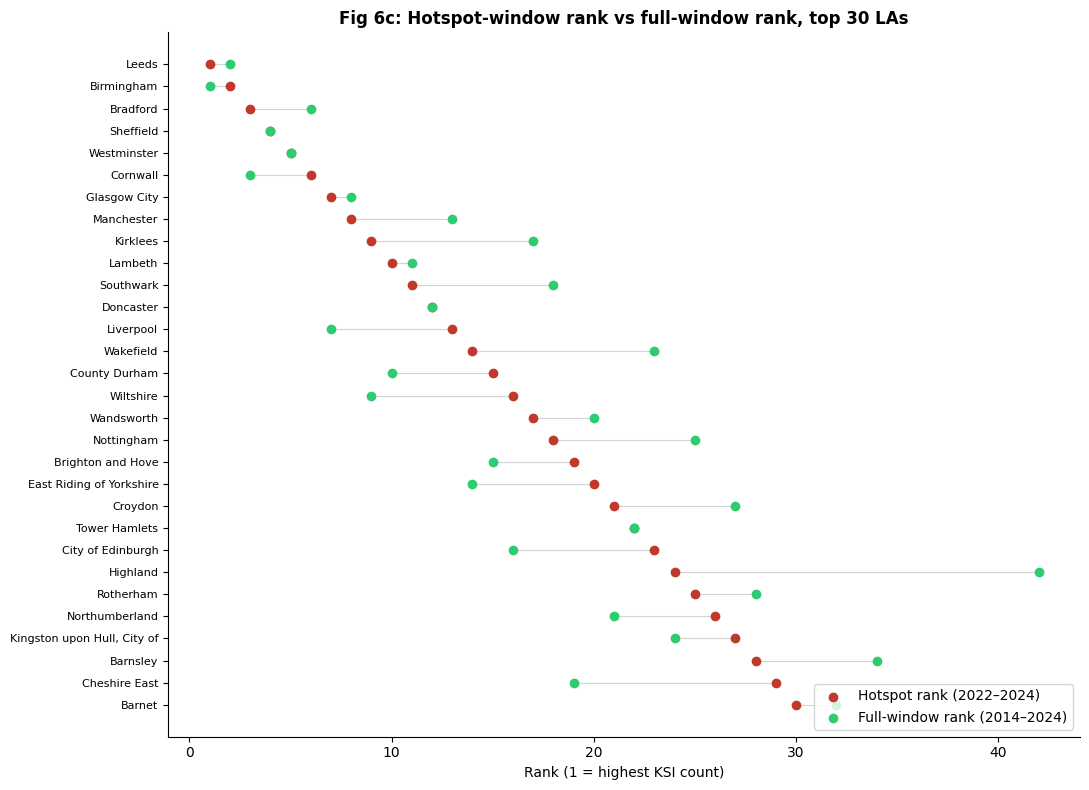

LAs with rank_shift >= 5: 265


In [47]:
full_la = (col[~col['provisional']]
           .groupby(['local_authority_ons_district', 'la_name'])
           .agg(KSI_full   = ('ksi', 'sum'),
                Total_full = ('collision_index', 'count'))
           .reset_index())
full_la['KSI_rate_full']   = full_la['KSI_full'] / full_la['Total_full'] * 100
full_la['rank_full_count'] = full_la['KSI_full'].rank(ascending=False, method='first').astype(int)
full_la['rank_full_rate']  = full_la['KSI_rate_full'].rank(ascending=False, method='first').astype(int)

merge = la.merge(full_la[['local_authority_ons_district','KSI_full','rank_full_count','rank_full_rate','KSI_rate_full']],
                 on='local_authority_ons_district', how='left')
merge['rank_hot_count'] = merge['KSI']     .rank(ascending=False, method='first').astype(int)
merge['rank_hot_rate']  = merge['KSI_rate'].rank(ascending=False, method='first').astype(int)
merge['rank_shift']     = (merge['rank_hot_count'] - merge['rank_full_count']).abs()
merge['flagged']        = merge['rank_shift'] >= 5

merge_sorted = merge.sort_values('rank_hot_count')
merge_sorted.to_csv(os.path.join(TAB_DIR, 'tab_la_rank_comparison.csv'), index=False)

top30 = merge_sorted.head(30).copy()
fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(top30))
ax.scatter(top30['rank_hot_count'], y,  color=PALETTE['fatal'],   label=f'Hotspot rank ({hotspot_window[0]}–{hotspot_window[1]})')
ax.scatter(top30['rank_full_count'], y, color=PALETTE['adjusted'], label=f'Full-window rank ({trend_window[0]}–{trend_window[1]})')
for i, row in top30.reset_index(drop=True).iterrows():
    ax.plot([row['rank_hot_count'], row['rank_full_count']], [i, i], color='lightgrey', lw=0.8, zorder=0)
ax.set_yticks(y)
ax.set_yticklabels(top30['la_name'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Rank (1 = highest KSI count)')
ax.set_title('Fig 6c: Hotspot-window rank vs full-window rank, top 30 LAs')
ax.legend(loc='lower right')
plt.tight_layout()
savefig('fig06c_rank_comparison')
plt.show()

n_flagged = merge_sorted['flagged'].sum()
print(f'LAs with rank_shift >= 5: {n_flagged}')


### 5d Three-way exposure robustness check

Three exposure denominators: count, collision rate, population rate. Population file optional — picked up by glob from `Data_Prep/Data/ons_la_population_*.csv`. If missing, runs two-way (count vs collision-rate) and prints a notice. Caleb's `max_rank_shift >= 5` flagging.

In [48]:
# Build base table from §5a's la dataframe
three_way = la[['local_authority_ons_district','la_name','KSI','KSI_rate','Total']].copy()
three_way['rank_count']    = three_way['KSI']     .rank(ascending=False, method='first').astype(int)
three_way['rank_collrate'] = three_way['KSI_rate'].rank(ascending=False, method='first').astype(int)

# Population — Caleb's format: skiprows=6, code col at idx 1, value at idx 2
pop_files = sorted(glob.glob(os.path.join(DATA_DIR, 'ons_la_population_*.csv')))
has_pop = False
if pop_files:
    pop_path = pop_files[-1]   # most recent
    try:
        pop = (pd.read_csv(pop_path, skiprows=6, header=None)[[1, 2]]
               .rename(columns={1: 'local_authority_ons_district', 2: 'population'}))
        pop['population'] = pd.to_numeric(pop['population'], errors='coerce')
        pop = pop[pop['local_authority_ons_district'].notna() & pop['population'].notna()]
        three_way = three_way.merge(pop, on='local_authority_ons_district', how='left')
        three_way['KSI_per_100k'] = three_way['KSI'] / three_way['population'] * 100_000
        # three_way['rank_poprate'] = three_way['KSI_per_100k'].rank(ascending=False, method='first').astype(int)
        three_way['rank_poprate'] = (three_way['KSI_per_100k']
                             .rank(ascending=False, method='first', na_option='bottom')
                             .astype(int))
        # Pop file parsing error fix ^
        has_pop = True
        print(f'Population file: {pop_path}')
    except Exception as e:
        print(f'Population file present at {pop_path} but failed to parse: {e}')
else:
    print(f'No population file in {DATA_DIR}/ons_la_population_*.csv — population-denominator analysis skipped.')

# Build flagged subset for output
rank_cols = ['rank_count', 'rank_collrate'] + (['rank_poprate'] if has_pop else [])
in_top = three_way[rank_cols].le(HOTSPOT_TOP_N).any(axis=1)
flagged = three_way[in_top].copy()
flagged['max_rank_shift'] = flagged[rank_cols].max(axis=1) - flagged[rank_cols].min(axis=1)
flagged['flagged']        = flagged['max_rank_shift'] >= 5
flagged_sorted = flagged.sort_values('rank_count')
flagged_sorted.to_csv(os.path.join(TAB_DIR, 'tab_three_way_exposure_robustness.csv'), index=False)

print(f'\nThree-way robustness: {len(flagged_sorted)} LAs in any top-{HOTSPOT_TOP_N} list, '
      f'{flagged_sorted["flagged"].sum()} with max_rank_shift >= 5')


Population file: /dcs/large/u2207745/ST422_Team1_Project/Final_Workflow/Data_Prep/Data/ons_la_population_2024.csv

Three-way robustness: 44 LAs in any top-15 list, 44 with max_rank_shift >= 5


### 5e Road-user-specific hotspots (Fig 6d)

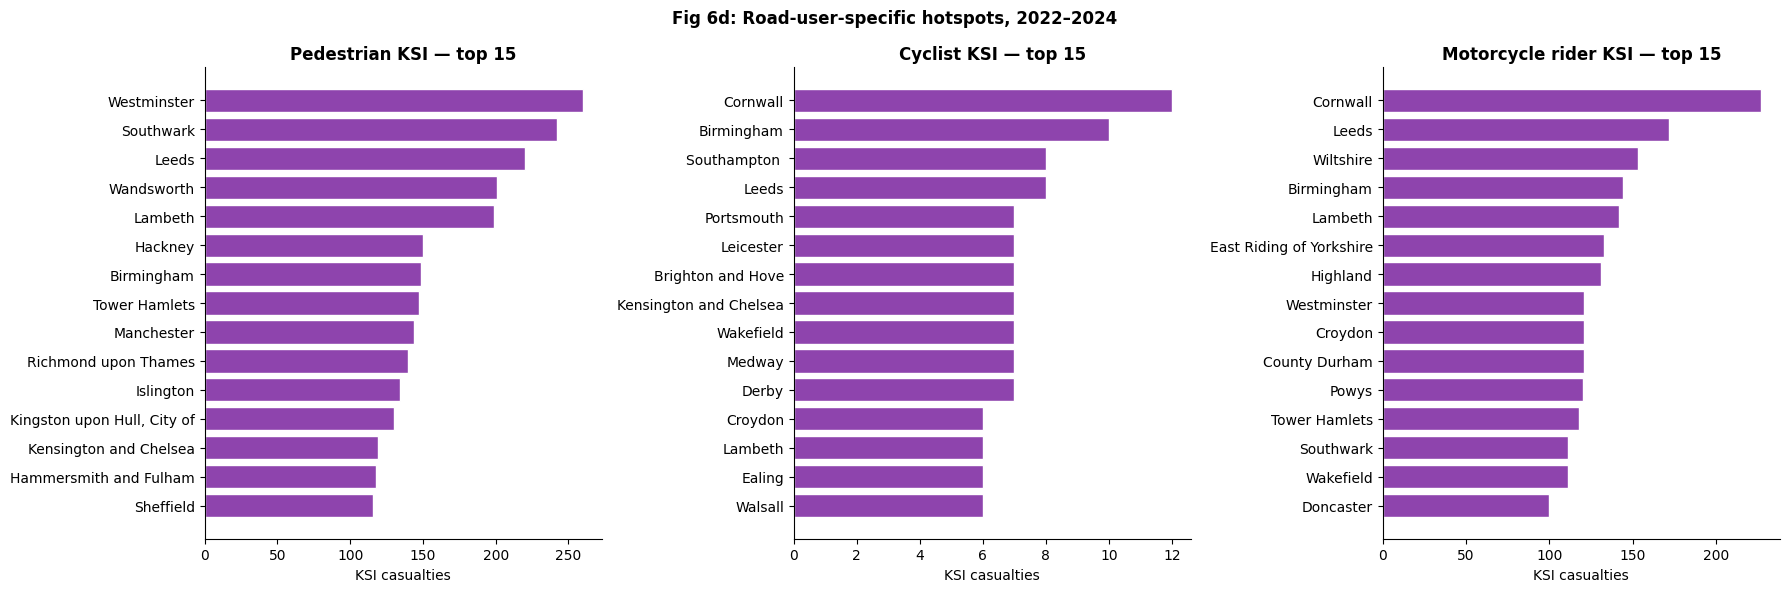

       road_user  top_n  overlap_with_overall
      Pedestrian     15                     7
         Cyclist     15                     5
Motorcycle rider     15                     9


In [49]:
ru_hot = cas_full[(cas_full['collision_year'].between(*hotspot_window)) &
                  (~cas_full['provisional']) &
                  (cas_full['casualty_severity'].isin([1, 2]))].copy()

groups = ['Pedestrian', 'Cyclist', 'Motorcycle rider']
ru_hot_dfs = []
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, grp in zip(axes, groups):
    sub = (ru_hot[ru_hot['road_user'] == grp]
           .groupby(['local_authority_ons_district', 'la_name'])
           .size().rename('KSI').reset_index())
    sub = sub.sort_values('KSI', ascending=False).head(HOTSPOT_TOP_N).iloc[::-1]
    ax.barh(sub['la_name'], sub['KSI'], color=PALETTE['ksi'], edgecolor='white')
    ax.set_title(f'{grp} KSI — top {HOTSPOT_TOP_N}')
    ax.set_xlabel('KSI casualties')
    ru_hot_dfs.append(sub.assign(road_user=grp))

plt.suptitle(f'Fig 6d: Road-user-specific hotspots, {hotspot_window[0]}–{hotspot_window[1]}', fontweight='bold')
plt.tight_layout()
savefig('fig06d_road_user_hotspots')
plt.show()

ru_hot_table = pd.concat(ru_hot_dfs, ignore_index=True)
ru_hot_table.to_csv(os.path.join(TAB_DIR, 'tab_road_user_hotspots.csv'), index=False)

overall_set = set(top_count['local_authority_ons_district'])
overlap_rows = []
for grp, df_g in zip(groups, ru_hot_dfs):
    grp_set = set(df_g['local_authority_ons_district'])
    overlap_rows.append({'road_user': grp, 'top_n': HOTSPOT_TOP_N,
                         'overlap_with_overall': len(grp_set & overall_set)})
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(os.path.join(TAB_DIR, 'tab_road_user_hotspot_overlap.csv'), index=False)
print(overlap_df.to_string(index=False))


## 6. Contributory factors — last `HOTSPOT_N` years (Figs 7, 8, 9)

### 6a Urban/rural

In [50]:
def severity_summary(df):
    s = (df.groupby(df['urban_or_rural_area'].map({1:'Urban', 2:'Rural', 3:'Unallocated'}))
         .agg(Fatal=('fatal','sum'),
              Serious=('collision_severity', lambda x: (x==2).sum()),
              Slight=('collision_severity',  lambda x: (x==3).sum()))
         .assign(Total=lambda d: d.sum(axis=1))
         .assign(KSI  =lambda d: d['Fatal'] + d['Serious'])
         .assign(KSI_pct=lambda d: d['KSI']/d['Total']*100,
                 Fatal_pct=lambda d: d['Fatal']/d['Total']*100))
    return s

ur = severity_summary(hot)
ur.to_csv(os.path.join(TAB_DIR, 'tab_urban_rural_severity.csv'))
print(ur.round(2).to_string())


                     Fatal  Serious  Slight   Total    KSI  KSI_pct  Fatal_pct
urban_or_rural_area                                                           
Rural                 2573    24150   63822   90545  26723    29.51       2.84
Unallocated              0        3      16      19      3    15.79       0.00
Urban                 1642    42163  157771  201576  43805    21.73       0.81


### 6b Speed limit and road type (Fig 7)

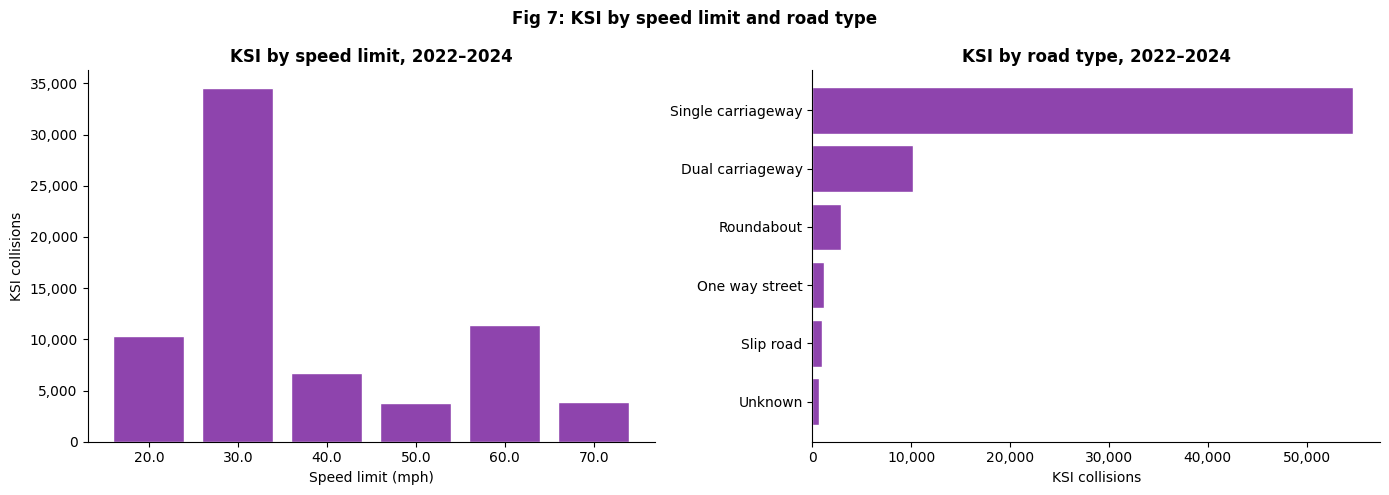

In [51]:
ksi_hot = hot[hot['ksi']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sp = ksi_hot.groupby('speed_limit').size().sort_index()
ax.bar(sp.index.astype(str), sp.values, color=PALETTE['ksi'], edgecolor='white')
ax.set_title(f'KSI by speed limit, {hotspot_window[0]}–{hotspot_window[1]}')
ax.set_xlabel('Speed limit (mph)')
ax.set_ylabel('KSI collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1]
rt = ksi_hot.groupby('road_type_label').size().sort_values(ascending=True)
ax.barh(rt.index, rt.values, color=PALETTE['ksi'], edgecolor='white')
ax.set_title(f'KSI by road type, {hotspot_window[0]}–{hotspot_window[1]}')
ax.set_xlabel('KSI collisions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 7: KSI by speed limit and road type', fontweight='bold')
plt.tight_layout()
savefig('fig07_speed_road')
plt.show()

sp.rename('KSI').to_csv(os.path.join(TAB_DIR, 'tab_ksi_by_speed.csv'))
rt.rename('KSI').to_csv(os.path.join(TAB_DIR, 'tab_ksi_by_road_type.csv'))


### 6c Day and hour (Fig 8)

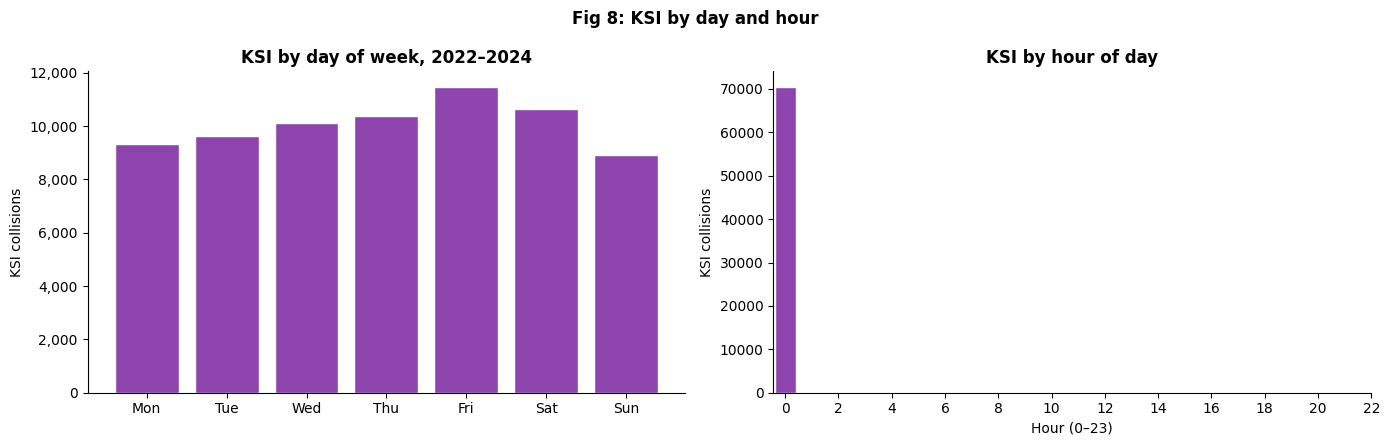

In [52]:
hot_with_hour = hot.copy()
hot_with_hour['hour'] = pd.to_datetime(hot_with_hour['date'], errors='coerce').dt.hour
if hot_with_hour['hour'].isna().all() and 'time' in hot_with_hour.columns:
    hot_with_hour['hour'] = pd.to_datetime(hot_with_hour['time'], errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_ksi = hot[hot['ksi']].groupby('day_label').size().reindex(day_order)
ax.bar(day_ksi.index, day_ksi.values, color=PALETTE['ksi'], edgecolor='white')
ax.set_title(f'KSI by day of week, {hotspot_window[0]}–{hotspot_window[1]}')
ax.set_ylabel('KSI collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1]
if hot_with_hour['hour'].notna().any():
    hr_ksi = hot_with_hour[hot_with_hour['ksi']].groupby('hour').size()
    ax.bar(hr_ksi.index, hr_ksi.values, color=PALETTE['ksi'], edgecolor='white')
    ax.set_title('KSI by hour of day')
    ax.set_xlabel('Hour (0–23)')
    ax.set_ylabel('KSI collisions')
    ax.set_xticks(range(0, 24, 2))
else:
    ax.text(0.5, 0.5, 'Hour-of-day not available in cleaned data', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Fig 8: KSI by day and hour', fontweight='bold')
plt.tight_layout()
savefig('fig08_day_hour')
plt.show()
day_ksi.rename('KSI').to_csv(os.path.join(TAB_DIR, 'tab_ksi_by_day.csv'))


### 6d Junction type (Fig 9)

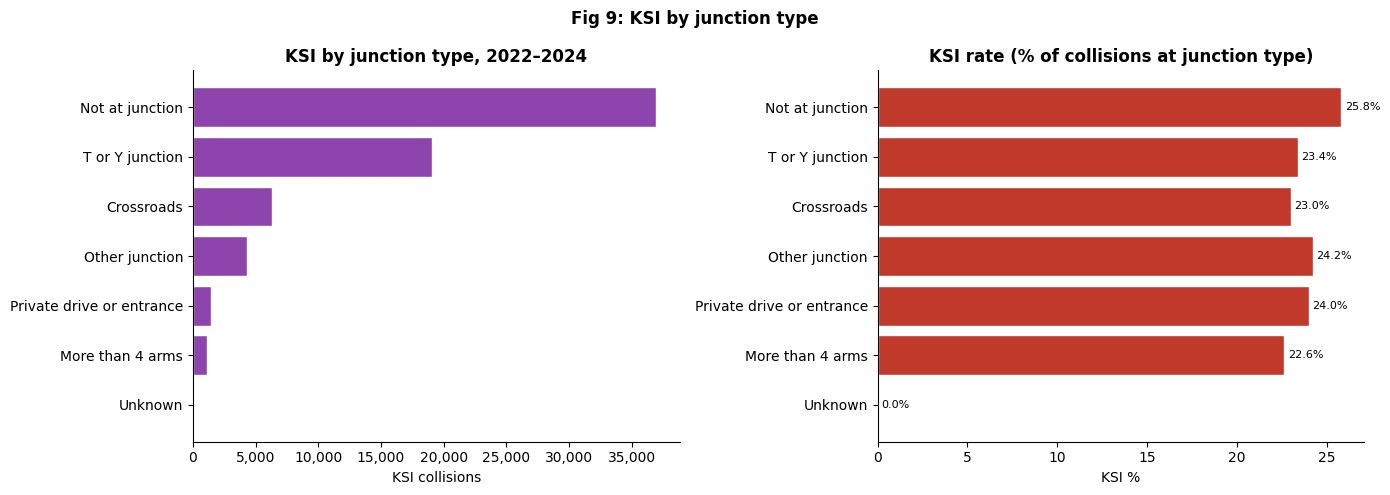

In [53]:
jn = (hot[hot['junction_label'].notna()]
      .groupby('junction_label')
      .agg(Fatal=('fatal','sum'),
           Serious=('collision_severity', lambda x: (x==2).sum()),
           Slight=('collision_severity', lambda x: (x==3).sum()))
      .assign(Total=lambda d: d.sum(axis=1))
      .assign(KSI=lambda d: d['Fatal'] + d['Serious'])
      .assign(KSI_pct=lambda d: d['KSI']/d['Total']*100)
      .sort_values('Total', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.barh(jn.index, jn['KSI'], color=PALETTE['ksi'], edgecolor='white')
ax.set_title(f'KSI by junction type, {hotspot_window[0]}–{hotspot_window[1]}')
ax.set_xlabel('KSI collisions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1]
ax.barh(jn.index, jn['KSI_pct'], color=PALETTE['fatal'], edgecolor='white')
for y, v in enumerate(jn['KSI_pct']):
    ax.text(v + 0.2, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_title('KSI rate (% of collisions at junction type)')
ax.set_xlabel('KSI %')

plt.suptitle('Fig 9: KSI by junction type', fontweight='bold')
plt.tight_layout()
savefig('fig09_junction_type')
plt.show()
jn.to_csv(os.path.join(TAB_DIR, 'tab_ksi_by_junction.csv'))


## 7. Local authority trend analysis (Figs 10, 11)

OLS slope per LA across `trend_window`, confirmed years only. LAs failing the completeness filter (§1.4) are already dropped. Within remaining LAs: the OLS table excludes those with mean KSI below `MIN_KSI_BASE` or fewer than `MIN_YEARS` years of data. Each LA fit gets a 95% CI, R², and `trend_shape` flag (linear if R² ≥ `LOW_R2`, else non-linear).

### 7a OLS setup

In [54]:
ksi_la = (col[~col['provisional'] & col['ksi']]
          .groupby(['la_name','collision_year'])
          .size().reset_index(name='KSI'))

# Backfill all (la, year) cells in trend window with 0 where missing
all_years = list(range(trend_window[0], trend_window[1] + 1))
all_las   = ksi_la['la_name'].unique()
full_grid = pd.MultiIndex.from_product([all_las, all_years], names=['la_name','collision_year']).to_frame(index=False)
ksi_la = full_grid.merge(ksi_la, on=['la_name','collision_year'], how='left').fillna({'KSI': 0})
ksi_la['KSI'] = ksi_la['KSI'].astype(int)


### 7b OLS fit per LA

In [55]:
ols_rows = []
for la_name, grp in ksi_la.groupby('la_name'):
    grp = grp.dropna(subset=['KSI','collision_year'])
    if len(grp) < MIN_YEARS: continue
    x = grp['collision_year'].values
    y = grp['KSI'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    t_crit   = stats.t.ppf(0.975, df=len(x)-2)
    ci_lo    = slope - t_crit * se
    ci_hi    = slope + t_crit * se
    ols_rows.append({
        'la_name': la_name, 'slope': slope,
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'std_err': se,
        'intercept': intercept, 'r_squared': r**2, 'p_value': p,
        'n_years': len(grp), 'mean_ksi': y.mean(),
    })
ols = pd.DataFrame(ols_rows)
ols = ols[ols['mean_ksi'] >= MIN_KSI_BASE].copy()
ols['trend_shape']      = ols['r_squared'].apply(lambda r: 'Linear' if r >= LOW_R2 else 'Non-linear')
ols['ci_includes_zero'] = (ols['ci_lo'] < 0) & (ols['ci_hi'] > 0)
ols = ols.sort_values('slope', ascending=False).reset_index(drop=True)
ols.to_csv(os.path.join(TAB_DIR, 'tab_la_ols_results.csv'), index=False)

n_eligible = len(ols)
n_signif_w = ((ols['p_value'] < 0.05) & (ols['slope'] > 0)).sum()
n_signif_i = ((ols['p_value'] < 0.05) & (ols['slope'] < 0)).sum()
print(f'LAs eligible for OLS                      : {n_eligible} (filter: mean KSI ≥ {MIN_KSI_BASE}, n_years ≥ {MIN_YEARS})')
print(f'Significant worsening (p<0.05, slope>0)   : {n_signif_w}')
print(f'Significant improving (p<0.05, slope<0)   : {n_signif_i}')
print(f'Linear trends (R² ≥ {LOW_R2})                : {(ols["trend_shape"]=="Linear").sum()}')


LAs eligible for OLS                      : 296 (filter: mean KSI ≥ 30, n_years ≥ 6)
Significant worsening (p<0.05, slope>0)   : 51
Significant improving (p<0.05, slope<0)   : 26
Linear trends (R² ≥ 0.5)                : 42


### 7c Worsening LAs — top `TOP_N_WORSENING` (Fig 10)

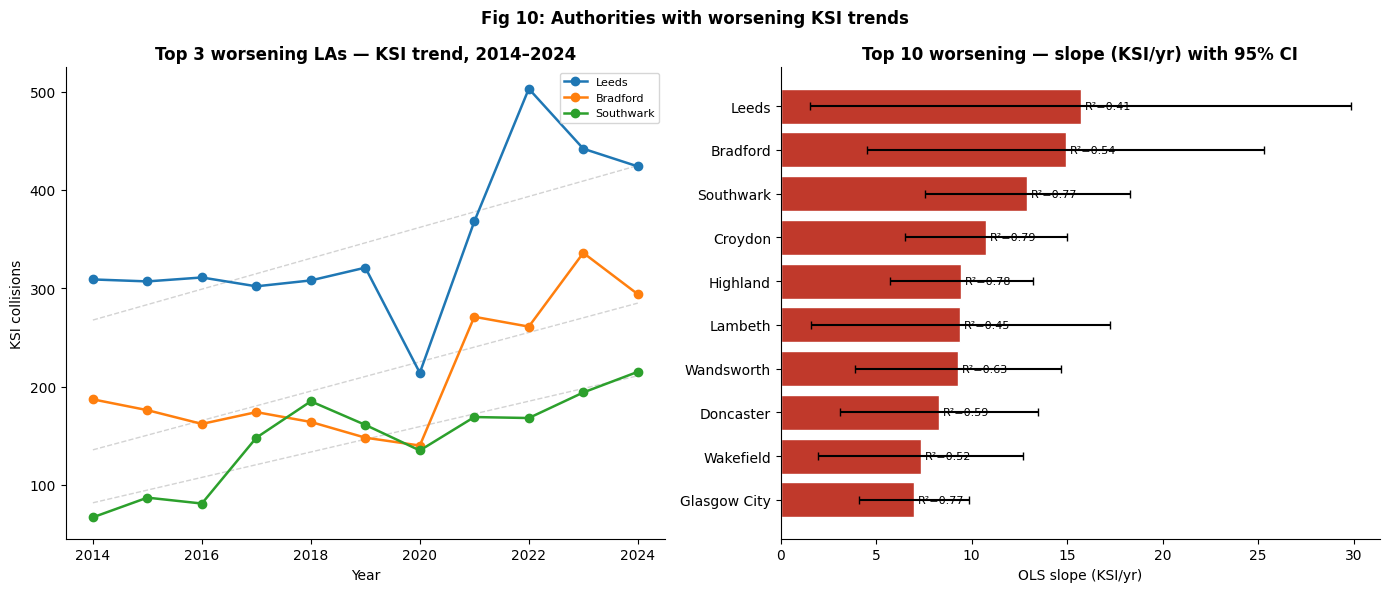

In [56]:
worsening = (ols[(ols['slope'] > 0) & (ols['p_value'] < 0.05)]
              .sort_values('slope', ascending=False)
              .reset_index(drop=True))
worsening.to_csv(os.path.join(TAB_DIR, 'tab_la_worsening.csv'), index=False)

top_w_names = worsening.head(TOP_N_WORSENING)['la_name'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
for la_name in worsening.head(TOP_N_LINES)['la_name']:
    sub = ksi_la[ksi_la['la_name'] == la_name]
    ax.plot(sub['collision_year'], sub['KSI'], marker='o', lw=1.8, label=la_name)
    s, i, *_ = stats.linregress(sub['collision_year'], sub['KSI'])
    xs = sub['collision_year']
    ax.plot(xs, i + s * xs, '--', lw=1, color='lightgrey', zorder=0)
ax.set_title(f'Top {TOP_N_LINES} worsening LAs — KSI trend, {trend_window[0]}–{trend_window[1]}')
ax.set_xlabel('Year')
ax.set_ylabel('KSI collisions')
ax.legend(fontsize=8, loc='best')

ax = axes[1]
top10_w = worsening.head(10).iloc[::-1]
ax.barh(top10_w['la_name'], top10_w['slope'],
        xerr=[top10_w['slope']-top10_w['ci_lo'], top10_w['ci_hi']-top10_w['slope']],
        color=PALETTE['worsening'], edgecolor='white', error_kw={'ecolor':'black','capsize':3})
ax.set_title('Top 10 worsening — slope (KSI/yr) with 95% CI')
ax.set_xlabel('OLS slope (KSI/yr)')
for y, (sl, r2) in enumerate(zip(top10_w['slope'], top10_w['r_squared'])):
    ax.text(sl + 0.2, y, f'R²={r2:.2f}', va='center', fontsize=8)

plt.suptitle('Fig 10: Authorities with worsening KSI trends', fontweight='bold')
plt.tight_layout()
savefig('fig10_worsening')
plt.show()


### 7d Improving LAs — top `TOP_N_IMPROVING` (Fig 11)

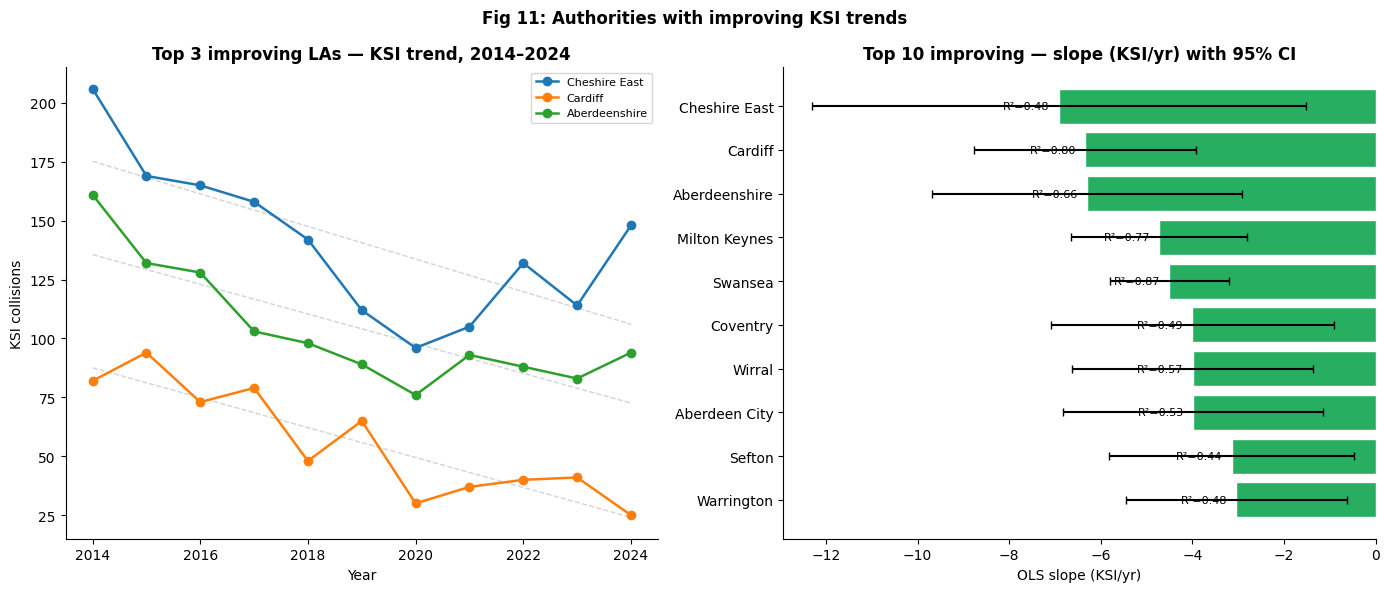

In [57]:
improving = (ols[(ols['slope'] < 0) & (ols['p_value'] < 0.05)]
              .sort_values('slope', ascending=True)
              .reset_index(drop=True))
improving.to_csv(os.path.join(TAB_DIR, 'tab_la_improving.csv'), index=False)

top_i_names = improving.head(TOP_N_IMPROVING)['la_name'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
for la_name in improving.head(TOP_N_LINES)['la_name']:
    sub = ksi_la[ksi_la['la_name'] == la_name]
    ax.plot(sub['collision_year'], sub['KSI'], marker='o', lw=1.8, label=la_name)
    s, i, *_ = stats.linregress(sub['collision_year'], sub['KSI'])
    xs = sub['collision_year']
    ax.plot(xs, i + s * xs, '--', lw=1, color='lightgrey', zorder=0)
ax.set_title(f'Top {TOP_N_LINES} improving LAs — KSI trend, {trend_window[0]}–{trend_window[1]}')
ax.set_xlabel('Year')
ax.set_ylabel('KSI collisions')
ax.legend(fontsize=8, loc='best')

ax = axes[1]
top10_i = improving.head(10).iloc[::-1]
ax.barh(top10_i['la_name'], top10_i['slope'],
        xerr=[top10_i['slope']-top10_i['ci_lo'], top10_i['ci_hi']-top10_i['slope']],
        color=PALETTE['improving'], edgecolor='white', error_kw={'ecolor':'black','capsize':3})
ax.set_title('Top 10 improving — slope (KSI/yr) with 95% CI')
ax.set_xlabel('OLS slope (KSI/yr)')
for y, (sl, r2) in enumerate(zip(top10_i['slope'], top10_i['r_squared'])):
    ax.text(sl - 0.2, y, f'R²={r2:.2f}', va='center', ha='right', fontsize=8)

plt.suptitle('Fig 11: Authorities with improving KSI trends', fontweight='bold')
plt.tight_layout()
savefig('fig11_improving')
plt.show()


### 7e Factor breakdown — base vs recent windows

In [58]:
shortlist_names = top_w_names + top_i_names
FACTORS = [('speed_limit',     'Speed limit'),
           ('road_type_label', 'Road type'),
           ('junction_label',  'Junction type'),
           ('ur_label',        'Urban/rural')]

def factor_breakdown(la_name):
    rows = []
    for factor, label in FACTORS:
        for window_name, years in [('base', BASE_YEARS), ('recent', RECENT_YEARS)]:
            sub = col[(col['la_name'] == la_name) &
                      (col['collision_year'].isin(years)) &
                      (col['ksi']) & (~col['provisional'])]
            counts = sub[factor].value_counts(dropna=False)
            for cat, n in counts.items():
                rows.append({'la_name': la_name, 'factor': label, 'category': str(cat),
                             'window': window_name, 'n_ksi': int(n)})
    return rows

fb_rows = []
for la_name in shortlist_names:
    fb_rows.extend(factor_breakdown(la_name))
fb = pd.DataFrame(fb_rows)
fb_pivot = fb.pivot_table(index=['la_name','factor','category'], columns='window',
                          values='n_ksi', fill_value=0).reset_index()
fb_pivot.columns.name = None
for c in ['base','recent']:
    if c not in fb_pivot.columns: fb_pivot[c] = 0
fb_pivot['delta']     = fb_pivot['recent'] - fb_pivot['base']
fb_pivot['pct_delta'] = np.where(fb_pivot['base'] > 0, fb_pivot['delta'] / fb_pivot['base'] * 100, np.nan)
fb_pivot.to_csv(os.path.join(TAB_DIR, 'tab_la_factor_breakdown.csv'), index=False)

print(f'Factor breakdown rows: {len(fb_pivot):,} ({len(shortlist_names)} LAs × {len(FACTORS)} factors × multiple categories)')


Factor breakdown rows: 194 (10 LAs × 4 factors × multiple categories)


## 8. Robustness checks (Fig 12)

Five checks following Caleb's spec: (1) exclude COVID years from OLS; (2) outcome = KSI rate instead of count; (3) sensitivity to `MIN_KSI_BASE` threshold; (4) sensitivity to `MIN_YEARS` threshold; (5) summary of top-N shortlist stability.

Top-N shortlist stability:
  worsening_top_n                                  5
  improving_top_n                                  5
  worsening_overlap_no_covid                       5
  worsening_overlap_rate_outcome                   1
  improving_overlap_no_covid                       4
  improving_overlap_rate_outcome                   0
  worsening_overlap_min_ksi_10                     5
  worsening_overlap_min_ksi_20                     5
  worsening_overlap_min_ksi_30                     5
  worsening_overlap_min_ksi_50                     5
  worsening_overlap_min_ksi_75                     5
  worsening_overlap_min_years_4                    5
  worsening_overlap_min_years_6                    5
  worsening_overlap_min_years_8                    5
  worsening_overlap_min_years_10                   5


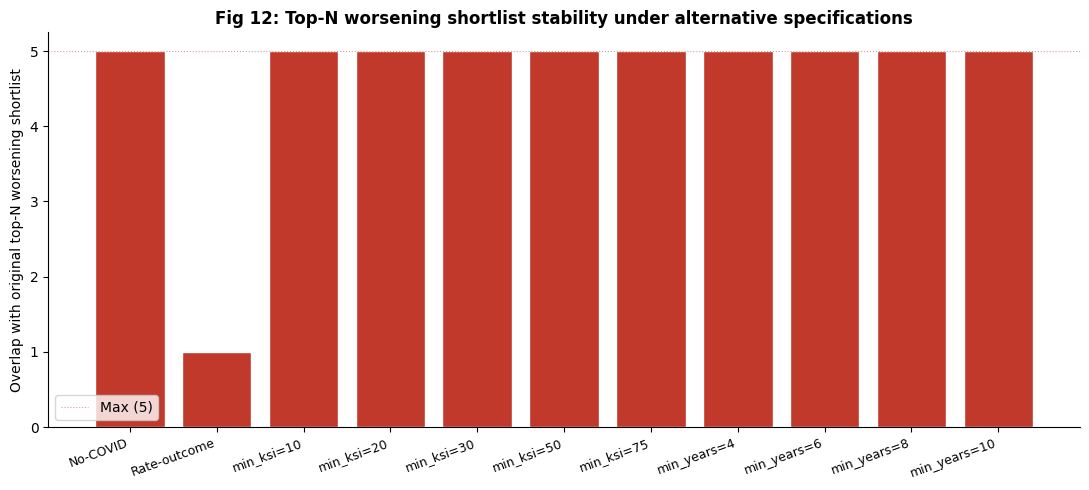

In [59]:
def fit_la_panel(df_panel, year_filter=None):
    if year_filter is not None:
        df_panel = df_panel[df_panel['collision_year'].isin(year_filter)]
    rows = []
    for la_name, grp in df_panel.groupby('la_name'):
        if len(grp) < MIN_YEARS: continue
        x, y = grp['collision_year'].values, grp['KSI'].values
        if np.std(x) == 0 or np.std(y) == 0: continue
        s, i, r, p, se = stats.linregress(x, y)
        rows.append({'la_name': la_name, 'slope': s, 'p_value': p, 'r_squared': r**2, 'mean_ksi': y.mean()})
    return pd.DataFrame(rows)

# Check 1 — exclude COVID
non_covid_years = [y for y in confirmed_years if y not in COVID_YEARS]
ols_no_covid = fit_la_panel(ksi_la, year_filter=non_covid_years)
ols_no_covid = ols_no_covid[ols_no_covid['mean_ksi'] >= MIN_KSI_BASE]
top_w_no_covid = set(ols_no_covid[(ols_no_covid['slope']>0) & (ols_no_covid['p_value']<0.05)]
                     .sort_values('slope', ascending=False).head(TOP_N_WORSENING)['la_name'])
top_i_no_covid = set(ols_no_covid[(ols_no_covid['slope']<0) & (ols_no_covid['p_value']<0.05)]
                     .sort_values('slope', ascending=True).head(TOP_N_IMPROVING)['la_name'])

# Check 2 — KSI rate outcome
total_la = (col[~col['provisional']]
            .groupby(['la_name','collision_year']).size().reset_index(name='Total'))
ksi_la_rate = ksi_la.merge(total_la, on=['la_name','collision_year'], how='left')
ksi_la_rate['KSI_rate'] = np.where(ksi_la_rate['Total']>0, ksi_la_rate['KSI']/ksi_la_rate['Total']*100, 0)
rate_rows = []
for la_name, grp in ksi_la_rate.groupby('la_name'):
    if len(grp) < MIN_YEARS: continue
    if np.std(grp['KSI_rate']) == 0: continue
    s, _, _, p, _ = stats.linregress(grp['collision_year'], grp['KSI_rate'])
    rate_rows.append({'la_name': la_name, 'slope': s, 'p_value': p, 'mean_ksi': grp['KSI'].mean()})
ols_rate = pd.DataFrame(rate_rows)
ols_rate = ols_rate[ols_rate['mean_ksi'] >= MIN_KSI_BASE]
top_w_rate = set(ols_rate[(ols_rate['slope']>0) & (ols_rate['p_value']<0.05)]
                 .sort_values('slope', ascending=False).head(TOP_N_WORSENING)['la_name'])
top_i_rate = set(ols_rate[(ols_rate['slope']<0) & (ols_rate['p_value']<0.05)]
                 .sort_values('slope', ascending=True).head(TOP_N_IMPROVING)['la_name'])

# Check 3 — MIN_KSI_BASE sensitivity
sens_rows = []
for thr in [10, 20, 30, 50, 75]:
    o = ols[ols['mean_ksi'] >= thr].sort_values('slope', ascending=False)
    if len(o) == 0: continue
    sens_rows.append({'threshold': thr, 'n_las': len(o),
                      'top_w': set(o[(o['slope']>0)&(o['p_value']<0.05)].head(TOP_N_WORSENING)['la_name'])})

# Check 4 — MIN_YEARS sensitivity
miny_rows = []
for thr in [4, 6, 8, 10]:
    rows = []
    for la_name, grp in ksi_la.groupby('la_name'):
        if len(grp) < thr: continue
        if np.std(grp['collision_year']) == 0: continue
        s, _, r, p, _ = stats.linregress(grp['collision_year'], grp['KSI'])
        rows.append({'la_name': la_name, 'slope': s, 'p_value': p, 'mean_ksi': grp['KSI'].mean()})
    o = pd.DataFrame(rows)
    o = o[o['mean_ksi'] >= MIN_KSI_BASE]
    if len(o) == 0: continue
    miny_rows.append({'min_years': thr, 'n_las': len(o),
                      'top_w': set(o[(o['slope']>0)&(o['p_value']<0.05)]
                                   .sort_values('slope', ascending=False).head(TOP_N_WORSENING)['la_name'])})

# Stability summary
top_w_orig = set(top_w_names)
top_i_orig = set(top_i_names)
stability = {
    'worsening_top_n':                          TOP_N_WORSENING,
    'improving_top_n':                          TOP_N_IMPROVING,
    'worsening_overlap_no_covid':               len(top_w_orig & top_w_no_covid),
    'worsening_overlap_rate_outcome':           len(top_w_orig & top_w_rate),
    'improving_overlap_no_covid':               len(top_i_orig & top_i_no_covid),
    'improving_overlap_rate_outcome':           len(top_i_orig & top_i_rate),
}
for r in sens_rows:
    stability[f'worsening_overlap_min_ksi_{r["threshold"]}'] = len(top_w_orig & r['top_w'])
for r in miny_rows:
    stability[f'worsening_overlap_min_years_{r["min_years"]}'] = len(top_w_orig & r['top_w'])

stability_df = pd.DataFrame(list(stability.items()), columns=['metric','value'])
stability_df.to_csv(os.path.join(TAB_DIR, 'tab_la_robustness_stability.csv'), index=False)
print('Top-N shortlist stability:')
for k, v in stability.items():
    print(f'  {k:<48} {v}')

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
labels = ['No-COVID', 'Rate-outcome'] + [f'min_ksi={r["threshold"]}' for r in sens_rows] + [f'min_years={r["min_years"]}' for r in miny_rows]
w_vals = ([stability['worsening_overlap_no_covid'], stability['worsening_overlap_rate_outcome']] +
          [stability[f'worsening_overlap_min_ksi_{r["threshold"]}'] for r in sens_rows] +
          [stability[f'worsening_overlap_min_years_{r["min_years"]}'] for r in miny_rows])
x = np.arange(len(labels))
ax.bar(x, w_vals, color=PALETTE['worsening'], edgecolor='white')
ax.axhline(TOP_N_WORSENING, color=PALETTE['worsening'], lw=0.8, ls=':', alpha=0.5, label=f'Max ({TOP_N_WORSENING})')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('Overlap with original top-N worsening shortlist')
ax.set_title('Fig 12: Top-N worsening shortlist stability under alternative specifications')
ax.legend()
plt.tight_layout()
savefig('fig12_robustness')
plt.show()


## 9. Diagnostics and modelling

(9a) National OLS residual diagnostics + COVID influence; (9b) per-LA bootstrap with divergence flagging; (9c) full M1–M7 stepwise GLM; (9d) AIC/BIC null vs linear vs quadratic + MLE comparison.

### 9a National adjusted-KSI OLS diagnostics + Cook's distance (Fig 13)

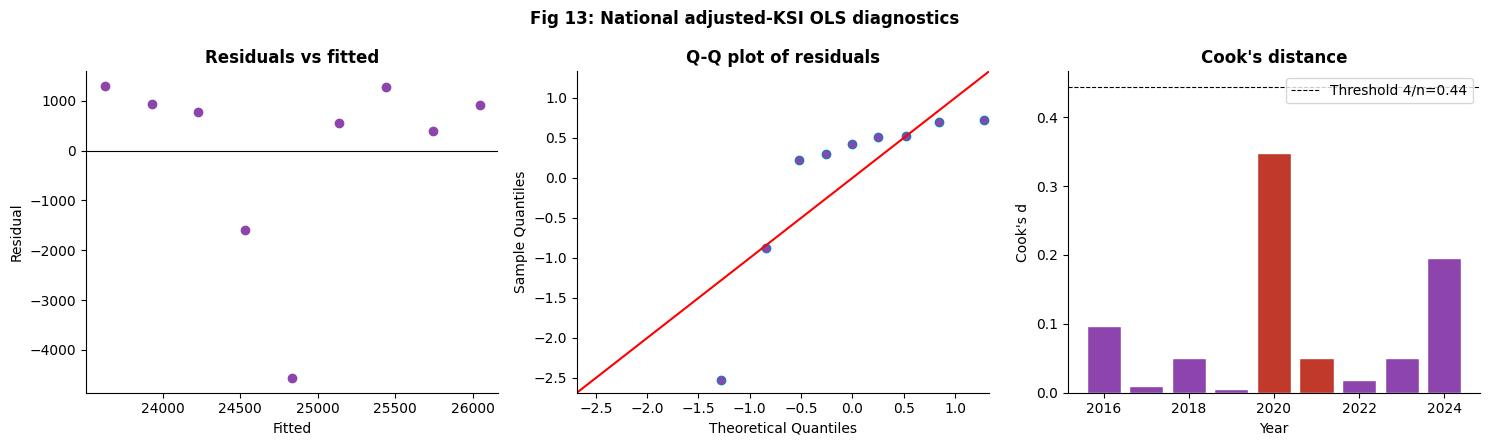

OLS R²: 0.157
Years with Cook's d > 4/n: []


In [60]:
import statsmodels.api as sm

X    = sm.add_constant(adj['collision_year'])
y    = adj['adj_ksi']
ols_nat = sm.OLS(y, X).fit()
resid    = ols_nat.resid
fitted   = ols_nat.fittedvalues
infl     = ols_nat.get_influence()
cooks_d  = infl.cooks_distance[0]

cooks_df = pd.DataFrame({'collision_year': adj['collision_year'].values,
                         'adj_ksi': y.values, 'fitted': fitted.values,
                         'residual': resid.values, 'cooks_d': cooks_d})
cooks_df.to_csv(os.path.join(TAB_DIR, 'tab_residual_diagnostics.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
ax.scatter(fitted, resid, color=PALETTE['ksi'])
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Fitted'); ax.set_ylabel('Residual'); ax.set_title('Residuals vs fitted')

ax = axes[1]
sm.qqplot(resid, line='45', fit=True, ax=ax, markerfacecolor=PALETTE['ksi'])
ax.set_title('Q-Q plot of residuals')

ax = axes[2]
ax.bar(adj['collision_year'], cooks_d,
       color=[PALETTE['fatal'] if y_ in COVID_YEARS else PALETTE['ksi'] for y_ in adj['collision_year']],
       edgecolor='white')
threshold = 4 / len(adj)
ax.axhline(threshold, color='black', lw=0.8, ls='--', label=f"Threshold 4/n={threshold:.2f}")
ax.set_title("Cook's distance"); ax.set_xlabel('Year'); ax.set_ylabel("Cook's d"); ax.legend()

plt.suptitle('Fig 13: National adjusted-KSI OLS diagnostics', fontweight='bold')
plt.tight_layout()
savefig('fig13_residual_diagnostics')
plt.show()

print(f'OLS R²: {ols_nat.rsquared:.3f}')
high_cook_years = [int(y_) for y_, d in zip(adj["collision_year"], cooks_d) if d > threshold]
print(f"Years with Cook's d > 4/n: {high_cook_years}")


### 9b Per-LA bootstrap with divergence flagging

In [61]:
print(f'=== Bootstrap CI validation — top {TOP_N_WORSENING} worsening LAs ({N_BOOTSTRAP} resamples) ===')
np.random.seed(RNG_SEED)
boot_rows = []
for la_name in top_w_names:
    sub = ksi_la[ksi_la['la_name'] == la_name].dropna()
    x = sub['collision_year'].values
    y = sub['KSI'].values
    xc = x - x.mean()
    slope_ols, _, _, _, se = stats.linregress(xc, y)
    t_crit    = stats.t.ppf(0.975, df=len(x)-2)
    ci_lo_ols = slope_ols - t_crit * se
    ci_hi_ols = slope_ols + t_crit * se
    boot_slopes = []
    idx = np.arange(len(x))
    for _ in range(N_BOOTSTRAP):
        bidx = np.random.choice(idx, size=len(idx), replace=True)
        bx = xc[bidx]; by = y[bidx]
        if np.std(bx) > 0:
            bs, _, _, _, _ = stats.linregress(bx, by)
            boot_slopes.append(bs)
    ci_lo_boot = np.percentile(boot_slopes, 2.5)
    ci_hi_boot = np.percentile(boot_slopes, 97.5)
    analytical_width = ci_hi_ols - ci_lo_ols
    bootstrap_width  = ci_hi_boot - ci_lo_boot
    diverges = bootstrap_width > 1.5 * analytical_width
    boot_rows.append({
        'la_name': la_name,
        'ols_slope': round(slope_ols, 2),
        'analytical_ci_lo': round(ci_lo_ols, 2),
        'analytical_ci_hi': round(ci_hi_ols, 2),
        'bootstrap_ci_lo': round(ci_lo_boot, 2),
        'bootstrap_ci_hi': round(ci_hi_boot, 2),
        'ci_diverges': diverges,
    })
boot_df = pd.DataFrame(boot_rows)
print(boot_df.to_string(index=False))
diverging = boot_df[boot_df['ci_diverges']]['la_name'].tolist()
if diverging:
    print(f'\nAuthorities where bootstrap CI diverges from analytical: {diverging}')
else:
    print('\nBootstrap and analytical CIs are consistent — OLS CI assumptions are reasonable.')
boot_df.to_csv(os.path.join(TAB_DIR, 'tab_bootstrap_ci_comparison.csv'), index=False)


=== Bootstrap CI validation — top 5 worsening LAs (1000 resamples) ===
  la_name  ols_slope  analytical_ci_lo  analytical_ci_hi  bootstrap_ci_lo  bootstrap_ci_hi  ci_diverges
    Leeds      15.72              1.56             29.88             4.49            26.63        False
 Bradford      14.93              4.54             25.32             3.27            26.35        False
Southwark      12.92              7.57             18.27             7.93            15.62        False
  Croydon      10.76              6.53             15.00             6.70            15.34        False
 Highland       9.46              5.71             13.22             5.63            12.31        False

Bootstrap and analytical CIs are consistent — OLS CI assumptions are reasonable.


### 9c Stepwise Poisson / Negative Binomial GLM (Figs 14a–d)

Aggregates KSI counts at LA × year × road_user × speed × road_type × urban/rural granularity. Uses population (or collision count) as offset. Tests dispersion, picks family. Fits seven nested models M1–M7 with progressively richer covariates and interactions. Compares by AIC; runs likelihood-ratio tests between successive models.

model_agg: (87117, 8)  |  offset: log(population)
Full Poisson dispersion ratio: 5.594
Overdispersed — using Negative Binomial throughout.
Fitting M1 — Year only... AIC = 437487.1
Fitting M2 — + Urban/Rural... AIC = 435887.0
Fitting M3 — + Road type + Speed... AIC = 415829.8
Fitting M4 — + Road user... AIC = 401505.0
Fitting M5 — + Speed × Road user... AIC = 397038.7
Fitting M6 — + Road type × Urban/Rural... AIC = 396673.0
Fitting M7 — + Road user × Urban/Rural... AIC = 395628.1

=== Stepwise model comparison ===
                         model      AIC  deviance  df_resid  pearson_chi2_df  n_params
                M1 — Year only 437487.1   87012.2     87106            2.625        11
            M2 — + Urban/Rural 435887.0   85408.2     87104            2.365        13
      M3 — + Road type + Speed 415829.8   65334.9     87096            1.442        21
              M4 — + Road user 401505.0   50992.2     87087            1.085        30
      M5 — + Speed × Road user 397038.7   4647

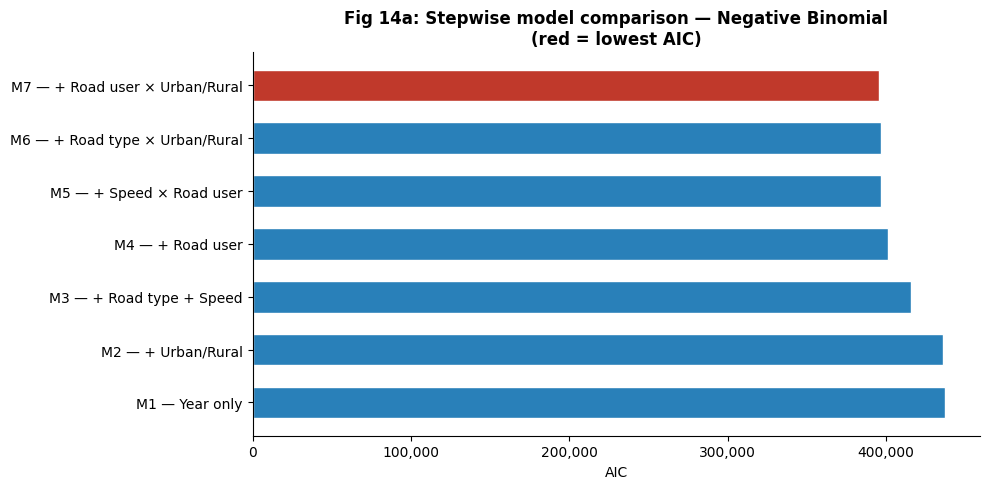

Best model by AIC: M7 — + Road user × Urban/Rural

=== Likelihood-ratio tests ===
                       simpler                         richer  lr_stat  df  p_value  significant_at_0.05
                M1 — Year only             M2 — + Urban/Rural  1604.01   2      0.0                 True
            M2 — + Urban/Rural       M3 — + Road type + Speed 20073.29   8      0.0                 True
      M3 — + Road type + Speed               M4 — + Road user 14342.73   9      0.0                 True
              M4 — + Road user       M5 — + Speed × Road user  4520.29  27      0.0                 True
      M5 — + Speed × Road user M6 — + Road type × Urban/Rural   383.69   9      0.0                 True
M6 — + Road type × Urban/Rural M7 — + Road user × Urban/Rural  1070.98  13      0.0                 True


In [62]:
import statsmodels.formula.api as smf
from scipy.stats import chi2 as chi2_dist

# Build the modelling panel
ROAD_USER_ORDER = ['Car occupant', 'Motorcycle rider', 'Pedestrian', 'Cyclist',
                   'Van occupant', 'HGV occupant', 'Minibus/bus occupant', 'Taxi/PHV occupant',
                   'Other', 'Unknown']

ksi_confirmed_full = cas_full[
    cas_full['ksi'] &
    (~cas_full['provisional']) &
    cas_full['la_name'].notna() &
    cas_full['collision_year'].between(*trend_window)
].copy()

ksi_confirmed_full['speed_cat'] = pd.cut(
    ksi_confirmed_full['speed_limit'],
    bins=[0, 20, 30, 40, 100],
    labels=['20 mph or below', '30 mph', '40 mph', '50 mph or above'],
    right=True
).astype(str).replace('nan', np.nan)

model_agg = (ksi_confirmed_full
             .groupby(['la_name','collision_year','road_user','speed_cat','road_type_label','ur_label'])
             .size().reset_index(name='ksi_count'))

# Offset: population if available, else collision count
if has_pop:
    pop_lookup = three_way[['local_authority_ons_district','la_name','population']].drop_duplicates('la_name')
    model_agg  = model_agg.merge(pop_lookup[['la_name','population']], on='la_name', how='left')
    offset_col, offset_note = 'population', 'log(population)'
else:
    coll_la = (col[(~col['provisional']) & col['collision_year'].between(*trend_window)]
               .groupby(['la_name','collision_year']).size().reset_index(name='n_collisions'))
    model_agg  = model_agg.merge(coll_la, on=['la_name','collision_year'], how='left')
    offset_col, offset_note = 'n_collisions', 'log(n_collisions)'
    print('Using collision count as offset (no population file).')

model_agg = model_agg.dropna(subset=['ksi_count', offset_col, 'road_user', 'speed_cat', 'road_type_label', 'ur_label']).copy()
model_agg[offset_col] = model_agg[offset_col].clip(lower=1)
model_agg['road_user'] = pd.Categorical(model_agg['road_user'], categories=ROAD_USER_ORDER)
model_agg['speed_cat'] = pd.Categorical(model_agg['speed_cat'],
    categories=['30 mph', '20 mph or below', '40 mph', '50 mph or above'])
model_agg.to_csv(os.path.join(TAB_DIR, 'tab_glm_model_agg.csv'), index=False)
print(f'model_agg: {model_agg.shape}  |  offset: {offset_note}')

def fit_glm(formula, data, offset_col, family):
    return smf.glm(formula=formula, data=data, family=family,
                   exposure=data[offset_col]).fit(disp=False)

def model_summary_row(label, model):
    disp = model.pearson_chi2 / model.df_resid
    return {'model': label, 'AIC': round(model.aic, 1), 'deviance': round(model.deviance, 1),
            'df_resid': int(model.df_resid), 'pearson_chi2_df': round(disp, 3),
            'n_params': int(model.df_model + 1)}

formula_full = 'ksi_count ~ road_user + speed_cat + road_type_label + ur_label + C(collision_year)'
poisson_full = fit_glm(formula_full, model_agg, offset_col, sm.families.Poisson())
disp_ratio   = poisson_full.pearson_chi2 / poisson_full.df_resid
print(f'Full Poisson dispersion ratio: {disp_ratio:.3f}')
if disp_ratio > 1.5:
    print('Overdispersed — using Negative Binomial throughout.')
    USE_FAMILY  = sm.families.NegativeBinomial()
    FAMILY_NAME = 'Negative Binomial'
else:
    print('No overdispersion — Poisson appropriate.')
    USE_FAMILY  = sm.families.Poisson()
    FAMILY_NAME = 'Poisson'

formulas = {
    'M1 — Year only':                      'ksi_count ~ C(collision_year)',
    'M2 — + Urban/Rural':                  'ksi_count ~ C(collision_year) + ur_label',
    'M3 — + Road type + Speed':            'ksi_count ~ C(collision_year) + ur_label + road_type_label + speed_cat',
    'M4 — + Road user':                    'ksi_count ~ C(collision_year) + ur_label + road_type_label + speed_cat + road_user',
    'M5 — + Speed × Road user':            'ksi_count ~ C(collision_year) + ur_label + road_type_label + speed_cat + road_user + speed_cat:road_user',
    'M6 — + Road type × Urban/Rural':      'ksi_count ~ C(collision_year) + ur_label + road_type_label + speed_cat + road_user + speed_cat:road_user + road_type_label:ur_label',
    'M7 — + Road user × Urban/Rural':      'ksi_count ~ C(collision_year) + ur_label + road_type_label + speed_cat + road_user + speed_cat:road_user + road_type_label:ur_label + road_user:ur_label',
}

fitted_models, comparison_rows = {}, []
for label, formula in formulas.items():
    print(f'Fitting {label}...', end=' ')
    try:
        m = fit_glm(formula, model_agg, offset_col, USE_FAMILY)
        fitted_models[label] = m
        comparison_rows.append(model_summary_row(label, m))
        print(f'AIC = {m.aic:.1f}')
    except Exception as e:
        print(f'FAILED — {e}')

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(TAB_DIR, 'tab_glm_stepwise_comparison.csv'), index=False)
print('\n=== Stepwise model comparison ===')
print(comparison_df.to_string(index=False))

# Fig 14a — AIC bar
fig, ax = plt.subplots(figsize=(10, 5))
best_idx = comparison_df['AIC'].idxmin()
colors_aic = [PALETTE['fatal'] if i == best_idx else PALETTE['slight'] for i in range(len(comparison_df))]
ax.barh(comparison_df['model'], comparison_df['AIC'], color=colors_aic, edgecolor='white', height=0.6)
ax.set_xlabel('AIC')
ax.set_title(f'Fig 14a: Stepwise model comparison — {FAMILY_NAME}\n(red = lowest AIC)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
savefig('fig14a_glm_stepwise_aic')
plt.show()

best_label = comparison_df.loc[best_idx, 'model']
print(f'Best model by AIC: {best_label}')

# LR tests between successive models
model_labels = list(formulas.keys())
lr_rows = []
for i in range(1, len(model_labels)):
    label_simple, label_complex = model_labels[i-1], model_labels[i]
    if label_simple in fitted_models and label_complex in fitted_models:
        m_s, m_c = fitted_models[label_simple], fitted_models[label_complex]
        lr_stat = 2 * (m_c.llf - m_s.llf)
        df_diff = int(m_s.df_resid - m_c.df_resid)
        p_lr    = 1 - chi2_dist.cdf(lr_stat, df_diff) if df_diff > 0 else np.nan
        lr_rows.append({'simpler': label_simple, 'richer': label_complex,
                        'lr_stat': round(lr_stat, 2), 'df': df_diff,
                        'p_value': round(p_lr, 6) if not np.isnan(p_lr) else np.nan,
                        'significant_at_0.05': (p_lr < 0.05) if not np.isnan(p_lr) else False})
lr_df = pd.DataFrame(lr_rows)
lr_df.to_csv(os.path.join(TAB_DIR, 'tab_glm_lr_tests.csv'), index=False)
print('\n=== Likelihood-ratio tests ===')
print(lr_df.to_string(index=False))


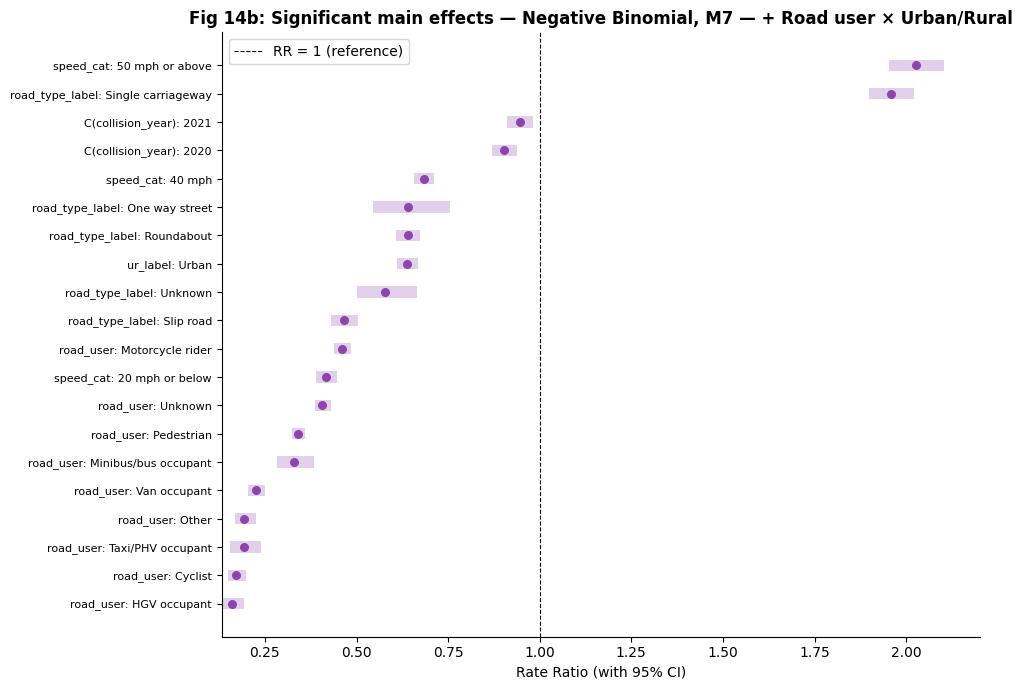


Targeted rate ratios:
                                 term       RR  CI_lower  CI_upper       p_value
        road_type_label[T.Roundabout] 0.639184  0.606958  0.673121  1.720507e-64
road_type_label[T.Single carriageway] 1.958382  1.898331  2.020333  0.000000e+00
         speed_cat[T.20 mph or below] 0.416418  0.389224  0.445511 1.338758e-142
                  speed_cat[T.40 mph] 0.684370  0.657414  0.712432  2.150904e-76
         speed_cat[T.50 mph or above] 2.026574  1.952814  2.103120 3.593225e-305
        road_user[T.Motorcycle rider] 0.460372  0.437880  0.484019 2.306423e-202
              road_user[T.Pedestrian] 0.341030  0.322991  0.360076  0.000000e+00
                 road_user[T.Cyclist] 0.171580  0.148919  0.197690 2.189843e-131


In [63]:
# ── Rate ratios from best GLM (M7) ───────────────────────────────────────────
best_model = fitted_models[best_label]

rr_df = pd.DataFrame({
    'term':      best_model.params.index,
    'coef':      best_model.params.values,
    'RR':        np.exp(best_model.params.values),
    'CI_lower':  np.exp(best_model.conf_int()[0].values),
    'CI_upper':  np.exp(best_model.conf_int()[1].values),
    'p_value':   best_model.pvalues.values,
    'significant': best_model.pvalues.values < 0.05,
})
rr_df.to_csv(os.path.join(TAB_DIR, 'tab_glm_best_model_rr.csv'), index=False)

# Targeted subset for client report — main effects only, no interactions
targeted_terms = [
    'road_type_label[T.Single carriageway]',
    'road_type_label[T.Dual carriageway]',
    'road_type_label[T.Roundabout]',
    'speed_cat[T.50 mph or above]',
    'speed_cat[T.40 mph]',
    'speed_cat[T.20 mph or below]',
    'road_user[T.Motorcycle rider]',
    'road_user[T.Pedestrian]',
    'road_user[T.Cyclist]',
    'ur_label[T.Rural]',
]
targeted = rr_df[rr_df['term'].isin(targeted_terms)].copy()
targeted.to_csv(os.path.join(TAB_DIR, 'tab_targeted_rate_ratios.csv'), index=False)

# Forest plot — significant main effects (no interactions)
sig_main = (rr_df[rr_df['significant'] &
                  ~rr_df['term'].str.contains(':') &
                  (rr_df['term'] != 'Intercept')]
            .sort_values('RR'))

fig, ax = plt.subplots(figsize=(10, max(6, len(sig_main) * 0.35)))
y = np.arange(len(sig_main))
ax.barh(y, sig_main['CI_upper'] - sig_main['CI_lower'],
        left=sig_main['CI_lower'], height=0.4,
        color=PALETTE['ksi'], alpha=0.25, edgecolor='none')
ax.scatter(sig_main['RR'], y, color=PALETTE['ksi'], zorder=3, s=30)
ax.axvline(1.0, color='black', lw=0.8, ls='--', label='RR = 1 (reference)')
ax.set_yticks(y)
ax.set_yticklabels(
    [t.replace('[T.', ': ').replace(']', '') for t in sig_main['term']],
    fontsize=8)
ax.set_xlabel('Rate Ratio (with 95% CI)')
ax.set_title(f'Fig 14b: Significant main effects — {FAMILY_NAME}, {best_label}')
ax.legend()
plt.tight_layout()
savefig('fig14b_glm_rr_forest')
plt.show()

print('\nTargeted rate ratios:')
print(targeted[['term', 'RR', 'CI_lower', 'CI_upper', 'p_value']].to_string(index=False))

### 9d AIC/BIC null vs linear vs quadratic (national adjusted-KSI)

In [64]:
null_mod = sm.OLS(adj['adj_ksi'], np.ones(len(adj))).fit()
lin_mod  = sm.OLS(adj['adj_ksi'], sm.add_constant(adj['collision_year'])).fit()
adj_q = adj.assign(year_sq=lambda d: d['collision_year']**2)
qua_mod  = sm.OLS(adj_q['adj_ksi'], sm.add_constant(adj_q[['collision_year','year_sq']])).fit()

cmp = pd.DataFrame({
    'model':   ['null', 'linear', 'quadratic'],
    'aic':     [null_mod.aic, lin_mod.aic, qua_mod.aic],
    'bic':     [null_mod.bic, lin_mod.bic, qua_mod.bic],
    'r2':      [0.0, lin_mod.rsquared, qua_mod.rsquared],
})
cmp.to_csv(os.path.join(TAB_DIR, 'tab_model_comparison.csv'), index=False)
print(cmp.to_string(index=False))

# MLE check
from scipy.optimize import minimize
def neg_log_lik(params, x, y):
    a, b, log_sigma = params
    sigma = np.exp(log_sigma)
    return -np.sum(stats.norm.logpdf(y, loc=a + b*x, scale=sigma))
res = minimize(neg_log_lik,
               x0=[lin_mod.params[0], lin_mod.params[1], np.log(np.std(lin_mod.resid))],
               args=(adj['collision_year'].values, adj['adj_ksi'].values))
print(f'\nMLE intercept: {res.x[0]:.2f}  vs  OLS: {lin_mod.params[0]:.2f}')
print(f'MLE slope    : {res.x[1]:+.2f}  vs  OLS: {lin_mod.params[1]:+.2f}')


    model        aic        bic       r2
     null 164.099092 164.296317 0.000000
   linear 164.566765 164.961214 0.156553
quadratic 162.965215 163.556889 0.434718

MLE intercept: 635119.70  vs  OLS: 635119.70
MLE slope    : -302.12  vs  OLS: -302.12


## 10. Policy evaluation — parameterised function

`compare_policy(treatment_la, control_la, policy_year, outcome)` runs a before/after comparison for any LA pair. No defaults are called; the analyst invokes from a separate cell with whichever case study is current.

In [65]:
def compare_policy(treatment_la, control_la, policy_year, outcome='ksi_rate', save=True):
    """
    Two-LA before/after comparison. Outcome: 'ksi_count' or 'ksi_rate'.
    Returns annual DataFrame; saves figure + CSV to Outputs/.
    """
    sub = (col[col['la_name'].isin([treatment_la, control_la]) & (~col['provisional'])]
           .groupby(['la_name','collision_year'])
           .agg(KSI=('ksi','sum'), Total=('collision_index','count'))
           .reset_index())
    sub['KSI_rate'] = sub['KSI'] / sub['Total'] * 100
    sub['period']   = np.where(sub['collision_year'] >= policy_year, 'after', 'before')
    sub['role']     = np.where(sub['la_name'] == treatment_la, 'treatment', 'control')

    metric = 'KSI' if outcome == 'ksi_count' else 'KSI_rate'

    fig, ax = plt.subplots(figsize=(10, 5))
    for role, colour in [('treatment', PALETTE['fatal']), ('control', PALETTE['adjusted'])]:
        d = sub[sub['role'] == role]
        if len(d) == 0: continue
        name = d['la_name'].iloc[0]
        ax.plot(d['collision_year'], d[metric], marker='o', lw=2, color=colour, label=f'{role}: {name}')
    ax.axvline(policy_year - 0.5, color='black', lw=1, ls='--', label=f'Policy: {policy_year}')
    ax.set_title(f'Policy comparison: outcome = {metric}')
    ax.set_xlabel('Year'); ax.set_ylabel(metric); ax.legend()

    if save:
        slug = f"{treatment_la}_vs_{control_la}_{policy_year}".replace(' ','_').replace('/','_')
        savefig(f'fig15_policy_{slug}')
        sub.to_csv(os.path.join(TAB_DIR, f'tab_policy_{slug}.csv'), index=False)
    plt.tight_layout()
    plt.show()
    return sub

print('compare_policy() defined. Invoke from a separate cell for any case study.')
print('Example: compare_policy("Liverpool", "Southwark", 2020, "ksi_rate")')


compare_policy() defined. Invoke from a separate cell for any case study.
Example: compare_policy("Liverpool", "Southwark", 2020, "ksi_rate")


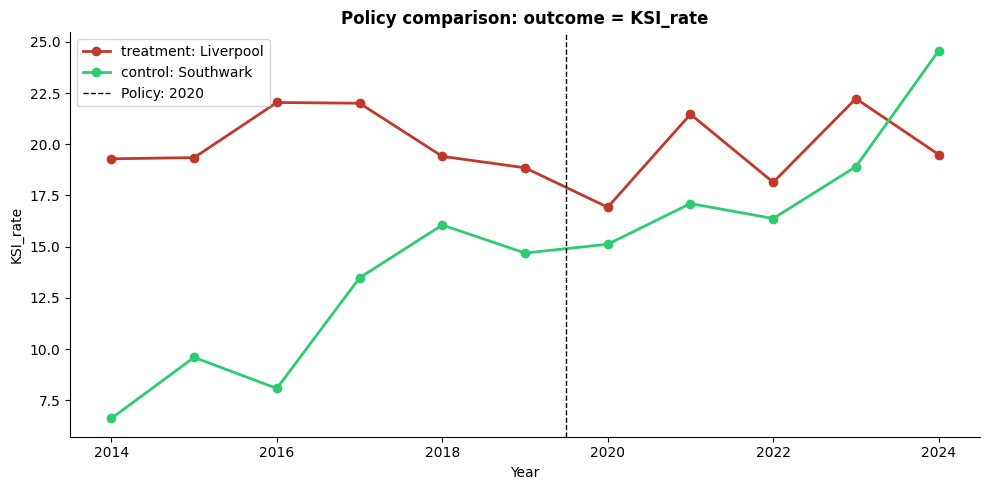

Liverpool                      Before: 20.2%   After: 19.7%   Δ: -0.5pp
Southwark                      Before: 11.4%   After: 18.4%   Δ: +7.0pp


In [66]:
# ── §10 Policy evaluation — Liverpool vs Southwark 20 mph comparison ─────────
liverpool_southwark = compare_policy(
    treatment_la = 'Liverpool',
    control_la   = 'Southwark',
    policy_year  = 2020,
    outcome      = 'ksi_rate',
    save         = True
)

# Print before/after summary for each LA
for la, grp in liverpool_southwark.groupby('la_name'):
    before = grp[grp['period'] == 'before']['KSI_rate'].mean()
    after  = grp[grp['period'] == 'after']['KSI_rate'].mean()
    print(f'{la:<30} Before: {before:.1f}%   After: {after:.1f}%   Δ: {after - before:+.1f}pp')

## 11. Material change threshold (Fig 17)

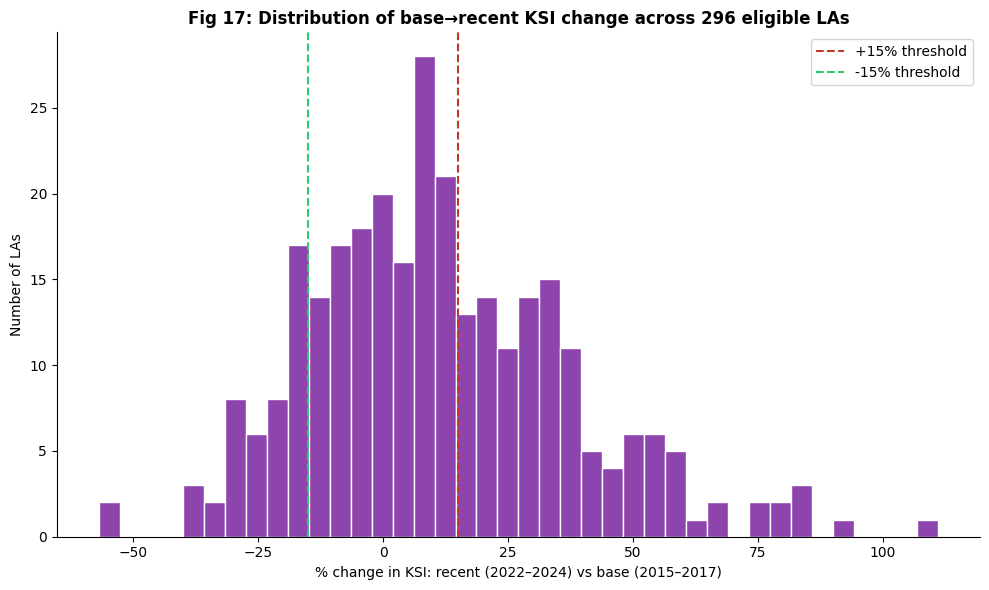

LAs flagged as materially worsened (+15% or more): 115
LAs flagged as materially improved (-15% or more): 46
LAs stable                                                : 135


In [67]:
mat = (col[(~col['provisional']) &
            ((col['collision_year'].isin(BASE_YEARS)) | (col['collision_year'].isin(RECENT_YEARS)))]
       .assign(window=lambda d: np.where(d['collision_year'].isin(BASE_YEARS), 'base', 'recent'))
       .groupby(['la_name','window'])['ksi'].sum()
       .unstack(fill_value=0).reset_index())
for c in ['base','recent']:
    if c not in mat.columns: mat[c] = 0
mat = mat[mat['la_name'].isin(ols['la_name'])].copy()
mat['delta']     = mat['recent'] - mat['base']
mat['pct_delta'] = np.where(mat['base'] > 0, mat['delta'] / mat['base'] * 100, np.nan)
mat['flag']      = np.where(mat['pct_delta'].abs() >= MATERIAL_CHANGE_PCT,
                           np.where(mat['pct_delta'] > 0, 'worsened', 'improved'), 'stable')

flagged = mat[mat['flag'] != 'stable'].sort_values('pct_delta')
flagged.to_csv(os.path.join(TAB_DIR, 'tab_material_change_flagged.csv'), index=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(mat['pct_delta'].dropna(), bins=40, color=PALETTE['ksi'], edgecolor='white')
ax.axvline( MATERIAL_CHANGE_PCT, color=PALETTE['fatal'],   ls='--', label=f'+{MATERIAL_CHANGE_PCT}% threshold')
ax.axvline(-MATERIAL_CHANGE_PCT, color=PALETTE['adjusted'], ls='--', label=f'-{MATERIAL_CHANGE_PCT}% threshold')
ax.set_xlabel(f'% change in KSI: recent ({recent_window[0]}–{recent_window[1]}) vs base ({base_window[0]}–{base_window[1]})')
ax.set_ylabel('Number of LAs')
ax.set_title(f'Fig 17: Distribution of base→recent KSI change across {len(mat)} eligible LAs')
ax.legend()
plt.tight_layout()
savefig('fig17_material_change')
plt.show()

print(f'LAs flagged as materially worsened (+{MATERIAL_CHANGE_PCT}% or more): {(mat["flag"]=="worsened").sum()}')
print(f'LAs flagged as materially improved (-{MATERIAL_CHANGE_PCT}% or more): {(mat["flag"]=="improved").sum()}')
print(f'LAs stable                                                : {(mat["flag"]=="stable").sum()}')


## 12. Traceability and run metadata

In [68]:
trace_rows = [
    ('National raw KSI trend',                 'fig03_national_ksi_trend.png',  'tab_ksi_trend_national.csv',          '§3b'),
    ('Raw vs IBRS-adjusted KSI',               'fig04_raw_vs_adjusted.png',     'tab_ksi_raw_vs_adjusted.csv',         '§3c'),
    ('STL decomposition — monthly KSI',    'fig_stl_decomposition.png',     '(no table)',                          '§3d'),
    ('Road user severity profile',             'fig05_road_user_severity.png',  'tab_road_user_severity.csv',          '§4'),
    ('Hotspots by KSI count',                  'fig06_hotspots_count_rate.png', 'tab_la_hotspots_count.csv',           '§5a'),
    ('Hotspots by KSI rate',                   'fig06_hotspots_count_rate.png', 'tab_la_hotspots_rate.csv',            '§5a'),
    ('Hotspot rank stability',                 'fig06c_rank_comparison.png',    'tab_la_rank_comparison.csv',          '§5c'),
    ('Three-way exposure robustness',          '(no fig)',                       'tab_three_way_exposure_robustness.csv','§5d'),
    ('Road-user-specific hotspots',            'fig06d_road_user_hotspots.png', 'tab_road_user_hotspot_overlap.csv',   '§5e'),
    ('KSI by speed and road type',             'fig07_speed_road.png',          'tab_ksi_by_speed.csv',                '§6b'),
    ('KSI by day and hour',                    'fig08_day_hour.png',            'tab_ksi_by_day.csv',                  '§6c'),
    ('KSI by junction type',                   'fig09_junction_type.png',       'tab_ksi_by_junction.csv',             '§6d'),
    ('Worsening LAs (top N)',                  'fig10_worsening.png',           'tab_la_worsening.csv',                '§7c'),
    ('Improving LAs (top N)',                  'fig11_improving.png',           'tab_la_improving.csv',                '§7d'),
    ('LA factor breakdown',                    '(no fig)',                       'tab_la_factor_breakdown.csv',         '§7e'),
    ('Robustness shortlist stability',         'fig12_robustness.png',          'tab_la_robustness_stability.csv',     '§8'),
    ('OLS residual diagnostics',               'fig13_residual_diagnostics.png','tab_residual_diagnostics.csv',        '§9a'),
    ('Per-LA bootstrap CI',                    '(no fig)',                       'tab_bootstrap_ci_comparison.csv',     '§9b'),
    ('Stepwise GLM comparison',                'fig14a_glm_stepwise_aic.png',   'tab_glm_stepwise_comparison.csv',     '§9c'),
    ('GLM LR tests',                           '(no fig)',                       'tab_glm_lr_tests.csv',                '§9c'),
    ('GLM best model rate ratios (M7)',    'fig14b_glm_rr_forest.png',      'tab_glm_best_model_rr.csv',           '§9c'),
    ('Targeted rate ratios — client report','(no fig)',                      'tab_targeted_rate_ratios.csv',        '§9c'),
    ('Null vs linear vs quadratic AIC/BIC',    '(no fig)',                       'tab_model_comparison.csv',            '§9d'),
    ('Policy comparison — Liverpool vs Southwark', 'fig15_policy_Liverpool_vs_Southwark_2020.png', 'tab_policy_Liverpool_vs_Southwark_2020.csv', '§10'),
    ('Material change flagged LAs',            'fig17_material_change.png',     'tab_material_change_flagged.csv',     '§11'),
]
trace = pd.DataFrame(trace_rows, columns=['claim','figure','table','section'])
trace.to_csv(os.path.join(OUTPUT_DIR, 'traceability.csv'), index=False)

meta = {
    'run_timestamp':       datetime.now().isoformat(timespec='seconds'),
    'year_start':          int(year_start),
    'year_end_confirmed':  int(year_end_confirmed),
    'provisional_year':    int(provisional_year) if provisional_year else None,
    'trend_window':        list(trend_window),
    'hotspot_window':      list(hotspot_window),
    'base_window':         list(base_window),
    'recent_window':       list(recent_window),
    'base_status':         base_status,
    'recent_status':       recent_status,
    'parameters': {
        'BASE_WINDOW_ANCHOR':    list(BASE_WINDOW_ANCHOR) if BASE_WINDOW_ANCHOR else None,
        'RECENT_WINDOW_ANCHOR':  list(RECENT_WINDOW_ANCHOR) if RECENT_WINDOW_ANCHOR else None,
        'RECENT_N':              RECENT_N,
        'HOTSPOT_N':             HOTSPOT_N,
        'HOTSPOT_TOP_N':         HOTSPOT_TOP_N,
        'MIN_KSI_BASE':          MIN_KSI_BASE,
        'MIN_YEARS':             MIN_YEARS,
        'LOW_R2':                LOW_R2,
        'TOP_N_WORSENING':       TOP_N_WORSENING,
        'TOP_N_IMPROVING':       TOP_N_IMPROVING,
        'TOP_N_LINES':           TOP_N_LINES,
        'MATERIAL_CHANGE_PCT':   MATERIAL_CHANGE_PCT,
        'MIN_COLLISIONS':        MIN_COLLISIONS,
        'N_BOOTSTRAP':           N_BOOTSTRAP,
        'RNG_SEED':              RNG_SEED,
        'IBRS_START':            IBRS_START,
        'COVID_YEARS':           COVID_YEARS,
    },
    'la_completeness': {
        'total_in_data':       int(n_total),
        'passed_filter':       int(n_complete),
        'dropped':             int(n_dropped),
    },
    'la_eligibility_for_ols': {
        'eligible':            int(n_eligible),
        'min_ksi_base':        MIN_KSI_BASE,
        'min_years':           MIN_YEARS,
    },
}
with open(os.path.join(OUTPUT_DIR, 'run_metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('Traceability table → Outputs/traceability.csv')
print('Run metadata       → Outputs/run_metadata.json')


Traceability table → Outputs/traceability.csv
Run metadata       → Outputs/run_metadata.json


## 13. Findings page — `Outputs/findings.html`

Self-contained HTML surfacing every LA flagged by any criterion. Sorted by number of criteria met (more = stronger combined evidence). The analyst decides priority.

**Criteria**

- **C1** Top `HOTSPOT_TOP_N` by KSI count
- **C2** Top `HOTSPOT_TOP_N` by KSI rate
- **C3** Significant worsening trend, p<0.05, top `TOP_N_WORSENING`
- **C4** Significant improving trend, p<0.05, top `TOP_N_IMPROVING`
- **C5** Material change ≥ `MATERIAL_CHANGE_PCT`%
- **C6** Pedestrian/cyclist/motorcyclist hotspot
- **C7** Stable shortlist member (resists no-COVID + rate-outcome alternatives)

In [69]:
def generate_findings_html():
    # Load tables produced by earlier sections
    t_count   = pd.read_csv(os.path.join(TAB_DIR, 'tab_la_hotspots_count.csv'))
    t_rate    = pd.read_csv(os.path.join(TAB_DIR, 'tab_la_hotspots_rate.csv'))
    t_worsen  = pd.read_csv(os.path.join(TAB_DIR, 'tab_la_worsening.csv'))
    t_improve = pd.read_csv(os.path.join(TAB_DIR, 'tab_la_improving.csv'))
    t_mat     = pd.read_csv(os.path.join(TAB_DIR, 'tab_material_change_flagged.csv'))
    t_ru      = pd.read_csv(os.path.join(TAB_DIR, 'tab_road_user_hotspots.csv'))
    t_fb      = pd.read_csv(os.path.join(TAB_DIR, 'tab_la_factor_breakdown.csv'))

    # Per-LA criterion flags, keyed by la_name
    criteria_map = {}
    def add(name, criterion, detail, code_la=None):
        if name not in criteria_map:
            criteria_map[name] = {'name': name, 'code': code_la or '', 'flags': {}}
        criteria_map[name]['flags'][criterion] = detail
        if code_la and not criteria_map[name]['code']:
            criteria_map[name]['code'] = code_la

    for _, r in t_count.iterrows():
        add(r['la_name'], 'C1', f"KSI count = {int(r['KSI']):,}",
            code_la=r.get('local_authority_ons_district', ''))
    for _, r in t_rate.iterrows():
        add(r['la_name'], 'C2', f"KSI rate = {r['KSI_rate']:.1f}%",
            code_la=r.get('local_authority_ons_district', ''))
    for _, r in t_worsen.head(TOP_N_WORSENING).iterrows():
        add(r['la_name'], 'C3', f"slope {r['slope']:+.1f} KSI/yr, p={r['p_value']:.4f}, R={r['r_squared']:.2f}")
    for _, r in t_improve.head(TOP_N_IMPROVING).iterrows():
        add(r['la_name'], 'C4', f"slope {r['slope']:+.1f} KSI/yr, p={r['p_value']:.4f}, R={r['r_squared']:.2f}")
    for _, r in t_mat.iterrows():
        add(r['la_name'], 'C5', f"{r['flag']} ({r['pct_delta']:+.1f}%)")
    for _, r in t_ru.iterrows():
        add(r['la_name'], 'C6', f"{r['road_user']}: {int(r['KSI']):,} KSI",
            code_la=r.get('local_authority_ons_district', ''))

    # C7 stable shortlist members
    stable_w = top_w_orig & top_w_no_covid & top_w_rate
    stable_i = top_i_orig & top_i_no_covid & top_i_rate
    for la_name in stable_w | stable_i:
        direction = 'worsening' if la_name in stable_w else 'improving'
        add(la_name, 'C7', f"stable {direction} (resists no-COVID + rate-outcome alternatives)")

    rows = []
    for name, info in criteria_map.items():
        rows.append({'name': name, 'code': info['code'], 'flags': info['flags'], 'n_flags': len(info['flags'])})
    rows.sort(key=lambda r: (-r['n_flags'], r['name']))

    fb_lookup = {}
    for la_name, g in t_fb.groupby('la_name'):
        fb_lookup[la_name] = g[['factor','category','base','recent','delta','pct_delta']].head(20)

    L = []
    L.append('<!DOCTYPE html>')
    L.append('<html><head><meta charset="utf-8"><title>ST422 Brief 8 Findings</title>')
    L.append('<style>')
    L.append("body { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; max-width: 1200px; margin: 2em auto; padding: 0 2em; color: #222; line-height: 1.5; }")
    L.append('h1 { border-bottom: 2px solid #2c3e50; padding-bottom: 0.3em; }')
    L.append('h2 { color: #2c3e50; margin-top: 2em; }')
    L.append('.meta { background: #f4f6f8; padding: 1em 1.5em; border-left: 4px solid #2c3e50; }')
    L.append('.crit-table, table.candidates, table.fb { border-collapse: collapse; margin: 1em 0; }')
    L.append('.crit-table td, .crit-table th { padding: 0.4em 0.8em; border: 1px solid #ddd; }')
    L.append('table.candidates { width: 100%; }')
    L.append('table.candidates th, table.candidates td { padding: 0.5em; border-bottom: 1px solid #eee; text-align: center; }')
    L.append('table.candidates th { background: #2c3e50; color: white; position: sticky; top: 0; }')
    L.append('table.candidates td.la-name { text-align: left; }')
    L.append('.la-code { color: #888; font-size: 0.85em; font-family: monospace; }')
    L.append('.n-flags { font-weight: bold; background: #ecf0f1; }')
    L.append('.hit { background: #d5f5e3; color: #196f3d; font-weight: bold; cursor: help; }')
    L.append('.miss { color: #ddd; }')
    L.append('.detail { background: #fafbfc; }')
    L.append('.detail ul { margin: 0.5em 0; }')
    L.append('table.fb { font-size: 0.9em; margin-top: 0.5em; }')
    L.append('table.fb td, table.fb th { padding: 0.3em 0.6em; border: 1px solid #ddd; }')
    L.append('button { cursor: pointer; padding: 0 0.6em; }')
    L.append('.caveats { background: #fef9e7; padding: 1em 1.5em; border-left: 4px solid #f1c40f; margin-top: 2em; }')
    L.append('</style>')
    L.append('<script>')
    L.append("function toggle(id) { var el = document.getElementById('detail-' + id); el.style.display = (el.style.display === 'none') ? 'table-row' : 'none'; }")
    L.append('</script>')
    L.append('</head><body>')

    L.append('<h1>ST422 Brief 8 Road safety findings</h1>')

    n_excluded = meta['la_completeness']['dropped']
    L.append('<div class="meta">')
    L.append(f"<strong>Run:</strong> {meta['run_timestamp']} &nbsp;&middot;&nbsp;")
    L.append(f"<strong>Confirmed years:</strong> {meta['year_start']}-{meta['year_end_confirmed']} &nbsp;&middot;&nbsp;")
    prov_str = meta['provisional_year'] if meta['provisional_year'] else 'none'
    L.append(f"<strong>Provisional:</strong> {prov_str} &nbsp;&middot;&nbsp;")
    L.append(f"<strong>Base:</strong> {meta['base_window'][0]}-{meta['base_window'][1]} &nbsp;&middot;&nbsp;")
    L.append(f"<strong>Recent:</strong> {meta['recent_window'][0]}-{meta['recent_window'][1]} &nbsp;&middot;&nbsp;")
    L.append(f"<strong>LAs in scope:</strong> {meta['la_eligibility_for_ols']['eligible']} eligible / {meta['la_completeness']['passed_filter']} passing completeness ({n_excluded} dropped)")
    L.append('</div>')

    L.append('<h2>How to read this page</h2>')
    L.append('<p>Each authority below was flagged by one or more criteria from the analysis. <strong>Authorities meeting more criteria have stronger combined evidence</strong>, but the priority decision rests with the client analyst local context, delivery capacity, and intervention feasibility are not captured here.</p>')
    L.append('<p>Hover over a tick to see the underlying value. Click <strong>+</strong> in the right-most column for the LA factor breakdown.</p>')

    L.append('<h2>Criteria reference</h2>')
    L.append('<table class="crit-table">')
    crit_defs = [
        ('C1', f'Top {HOTSPOT_TOP_N} LA by KSI count over {hotspot_window[0]}-{hotspot_window[1]}'),
        ('C2', f'Top {HOTSPOT_TOP_N} LA by KSI rate over {hotspot_window[0]}-{hotspot_window[1]} (excluding LAs with fewer than {MIN_COLLISIONS} total collisions)'),
        ('C3', f'Significant worsening trend (slope > 0, p < 0.05) over {trend_window[0]}-{trend_window[1]}, top {TOP_N_WORSENING}'),
        ('C4', f'Significant improving trend (slope < 0, p < 0.05) over {trend_window[0]}-{trend_window[1]}, top {TOP_N_IMPROVING}'),
        ('C5', f'Material change in KSI between {base_window[0]}-{base_window[1]} and {recent_window[0]}-{recent_window[1]} (>= {MATERIAL_CHANGE_PCT}% in either direction)'),
        ('C6', f'Pedestrian, cyclist, or motorcyclist hotspot top {HOTSPOT_TOP_N} for that road user'),
        ('C7', 'Member of the worsening or improving shortlist that survives COVID exclusion AND switching from count to rate as the outcome'),
    ]
    for ck, cd in crit_defs:
        L.append(f'<tr><td><strong>{ck}</strong></td><td>{cd}</td></tr>')
    L.append('</table>')

    L.append('<h2>National-level numbers</h2><ul>')
    L.append(f'<li>Raw KSI national slope ({IBRS_START}-{year_end_confirmed}): <strong>{slope_raw_w:+.0f} per year</strong> (p={p_raw_w:.4f})</li>')
    L.append(f'<li>IBRS-adjusted KSI national slope ({IBRS_START}-{year_end_confirmed}): <strong>{slope_adj_w:+.0f} per year</strong> (p={p_adj_w:.4f})</li>')
    raw_dir = 'rising' if slope_raw_w > 0 else 'falling'
    adj_dir = 'rising' if slope_adj_w > 0 else 'falling'
    L.append(f'<li>Direction: raw is <strong>{raw_dir}</strong>, adjusted is <strong>{adj_dir}</strong></li>')
    L.append('</ul>')

    L.append(f'<h2>Candidate authorities ({len(rows)})</h2>')
    L.append('<p>Sorted by number of criteria met (descending), then by LA name.</p>')
    L.append('<table class="candidates">')
    L.append('<thead><tr><th>Local Authority</th><th># Crit</th><th>C1</th><th>C2</th><th>C3</th><th>C4</th><th>C5</th><th>C6</th><th>C7</th><th>Detail</th></tr></thead>')
    L.append('<tbody>')

    for i, r in enumerate(rows):
        slug = ''.join(c if c.isalnum() else '_' for c in r['name']) + f'_{i}'
        flag_cells = ''
        for ck in ['C1','C2','C3','C4','C5','C6','C7']:
            d = r['flags'].get(ck, '')
            if d:
                d_safe = d.replace('"', '&quot;')
                flag_cells += f'<td class="hit" title="{d_safe}">&check;</td>'
            else:
                flag_cells += '<td class="miss"></td>'
        L.append('<tr class="la-row">')
        code_disp = f'<br><span class="la-code">{r["code"]}</span>' if r['code'] else ''
        L.append(f'<td class="la-name"><strong>{r["name"]}</strong>{code_disp}</td>')
        L.append(f'<td class="n-flags">{r["n_flags"]}</td>')
        L.append(flag_cells)
        L.append(f'<td><button onclick="toggle(\'{slug}\')">+</button></td>')
        L.append('</tr>')

        L.append(f'<tr id="detail-{slug}" class="detail" style="display:none">')
        L.append('<td colspan="10"><ul>')
        for ck, d in r['flags'].items():
            L.append(f'<li><strong>{ck}:</strong> {d}</li>')
        L.append('</ul>')
        fb = fb_lookup.get(r['name'], pd.DataFrame())
        if len(fb):
            L.append('<h4>Factor breakdown base vs recent windows</h4>')
            L.append('<table class="fb"><tr><th>Factor</th><th>Category</th><th>Base</th><th>Recent</th><th>Delta</th><th>Delta %</th></tr>')
            for _, fr in fb.iterrows():
                pct = '' if pd.isna(fr['pct_delta']) else f'{fr["pct_delta"]:+.0f}%'
                L.append(f'<tr><td>{fr["factor"]}</td><td>{fr["category"]}</td><td>{int(fr["base"])}</td><td>{int(fr["recent"])}</td><td>{int(fr["delta"]):+}</td><td>{pct}</td></tr>')
            L.append('</table>')
        else:
            L.append('<em>(factor breakdown only computed for LAs in shortlists)</em>')
        L.append('</td></tr>')

    L.append('</tbody></table>')

    L.append('<div class="caveats"><h3>Caveats</h3><ul>')
    L.append('<li><strong>IBRS adoption</strong> drives most of the apparent rise in raw serious-injury counts. Use the adjusted series for trend interpretation.</li>')
    L.append('<li><strong>Provisional data</strong> is partial-year and reporting practice for the latest year may not be stable. Provisional-year rows are excluded from all OLS fits.</li>')
    L.append(f'<li><strong>Boundary reorganisation</strong> excluded {n_excluded} authorities from longitudinal analysis (no record in every year of base AND recent windows).</li>')
    L.append(f'<li><strong>Size threshold</strong>: authorities with mean KSI below {MIN_KSI_BASE} or fewer than {MIN_YEARS} years of data are excluded from OLS.</li>')
    L.append('</ul></div>')

    L.append('</body></html>')

    out_path = os.path.join(OUTPUT_DIR, 'findings.html')
    with open(out_path, 'w') as f:
        f.write('\n'.join(L))
    print(f'Findings HTML written -> {out_path}')
    print(f'Candidate authorities surfaced: {len(rows)}')

generate_findings_html()


Findings HTML written -> /dcs/large/u2207745/ST422_Team1_Project/Final_Workflow/Data_Analysis/Outputs/findings.html
Candidate authorities surfaced: 174


## End of analysis

Outputs in `./Outputs/`:
- `figures/` — every numbered figure
- `tables/` — every analytical table
- `traceability.csv` — claim → figure/table/section mapping
- `run_metadata.json` — windows, parameters, timestamp
- `findings.html` — single-file evidence-assembly page

**To re-run for a future year:** rerun `Data_Prep/data_cleaning.ipynb` with new `YEAR_END` / `PROVISIONAL_YEAR`, then run this notebook top to bottom. If `BASE_WINDOW_ANCHOR` becomes unreachable, the §0 status print will say so and the workflow falls back to auto-derived windows. Set anchors to `None` for fully auto behaviour.